# Project : appstore strategy games eda & visualization
- 프로젝트 목적 : 앱스토어 전략 게임 데이터를 바탕으로 EDA 및 시각화
- 데이터 정보
    - 규모 : 17007 rows * 18 columns
    - 기간 : ???
    - 출처 : [(Kaggle) 17K Mobile Strategy Games Dataset](https://www.kaggle.com/datasets/tristan581/17k-apple-app-store-strategy-games)
- 최종 수정 : 2026-06-06

## 라이브러리 import

In [1]:
# 데이터 처리
import numpy as np
import pandas as pd
from scipy import stats

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
# 시각화 기본 세팅
sns.set_theme(style="whitegrid")

## 한글 깨짐 방지
# 윈도우
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False
# 맥
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 그 외
# 경고 무시
import warnings
warnings.filterwarnings("ignore")

# 시스템
import os
import gc

## 데이터 로드

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tristan581/17k-apple-app-store-strategy-games")

print("Path to dataset files:", path)

df = pd.read_csv(f"{path}/appstore_games.csv")
print(df.shape)
df.head()

Path to dataset files: /Users/hyun/.cache/kagglehub/datasets/tristan581/17k-apple-app-store-strategy-games/versions/3
(17007, 18)


,URL,ID,Name,Subtitle,Icon URL,Average User Rating,User Rating Count,Price,In-app Purchases,Description,Developer,Age Rating,Languages,Size,Primary Genre,Genres,Original Release Date,Current Version Release Date
0,https://apps.apple.com/us/app/sudoku/id284921427,284921427,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,4.0,3553.0,2.99,NaN,"Join over 21,000,000 of our fans and download ...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",15853568.0,Games,"Games, Strategy, Puzzle",11/07/2008,30/05/2017
1,https://apps.apple.com/us/app/reversi/id284926400,284926400,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purpl...,3.5,284.0,1.99,NaN,"The classic game of Reversi, also known as Oth...",Kiss The Machine,4+,EN,12328960.0,Games,"Games, Strategy, Board",11/07/2008,17/05/2018
2,https://apps.apple.com/us/app/morocco/id284946595,284946595,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.0,8376.0,0.00,NaN,Play the classic strategy game Othello (also k...,Bayou Games,4+,EN,674816.0,Games,"Games, Board, Strategy",11/07/2008,5/09/2017
3,https://apps.apple.com/us/app/sudoku-free/id28...,285755462,Sudoku (Free),NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.5,190394.0,0.00,NaN,"Top 100 free app for over a year.\nRated ""Best...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",21552128.0,Games,"Games, Strategy, Puzzle",23/07/2008,30/05/2017
4,https://apps.apple.com/us/app/senet-deluxe/id2...,285831220,Senet Deluxe,NaN,https://is1-ssl.mzstatic.com/image/thumb/Purpl...,3.5,28.0,2.99,NaN,"""Senet Deluxe - The Ancient Game of Life and A...",RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU...",34689024.0,Games,"Games, Strategy, Board, Education",18/07/2008,22/07/2018


- URL 칼럼 drop
- Languages 어떻게 처리할지??
- Size : 1024(KB) or 1024*1024(MB) 로 나눠서 값 크기 조절
- Original Release Date & Current Version Release Date 칼럼 datetime 변환
    - Current - Original 을 기간으로 파생변수 생성?

## 데이터 탐색

### URL drop, Date 칼럼들 datetime 변환

URL

In [3]:
df.drop(columns=['URL'], inplace=True)
df.head()

,ID,Name,Subtitle,Icon URL,Average User Rating,User Rating Count,Price,In-app Purchases,Description,Developer,Age Rating,Languages,Size,Primary Genre,Genres,Original Release Date,Current Version Release Date
0,284921427,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,4.0,3553.0,2.99,NaN,"Join over 21,000,000 of our fans and download ...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",15853568.0,Games,"Games, Strategy, Puzzle",11/07/2008,30/05/2017
1,284926400,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purpl...,3.5,284.0,1.99,NaN,"The classic game of Reversi, also known as Oth...",Kiss The Machine,4+,EN,12328960.0,Games,"Games, Strategy, Board",11/07/2008,17/05/2018
2,284946595,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.0,8376.0,0.00,NaN,Play the classic strategy game Othello (also k...,Bayou Games,4+,EN,674816.0,Games,"Games, Board, Strategy",11/07/2008,5/09/2017
3,285755462,Sudoku (Free),NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.5,190394.0,0.00,NaN,"Top 100 free app for over a year.\nRated ""Best...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT...",21552128.0,Games,"Games, Strategy, Puzzle",23/07/2008,30/05/2017
4,285831220,Senet Deluxe,NaN,https://is1-ssl.mzstatic.com/image/thumb/Purpl...,3.5,28.0,2.99,NaN,"""Senet Deluxe - The Ancient Game of Life and A...",RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU...",34689024.0,Games,"Games, Strategy, Board, Education",18/07/2008,22/07/2018


Date관련

In [4]:
df['Original Release Date'] = pd.to_datetime(df['Original Release Date'], format='%d/%m/%Y')
df['Current Version Release Date'] = pd.to_datetime(df['Current Version Release Date'], format='%d/%m/%Y')

### Info, Describe, Null 체크

In [5]:
# 데이터 확인
print("============= info =============")
print(df.info(), "\n")
print("============= describe =============")
print(df.describe(), "\n")
print("============= null sum =============")
print(df.isnull().sum())
print("total Null:", df.isnull().sum().sum(), "\n")

============= info =============
<class 'pandas.DataFrame'>
RangeIndex: 17007 entries, 0 to 17006
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            17007 non-null  int64         
 1   Name                          17007 non-null  str           
 2   Subtitle                      5261 non-null   str           
 3   Icon URL                      17007 non-null  str           
 4   Average User Rating           7561 non-null   float64       
 5   User Rating Count             7561 non-null   float64       
 6   Price                         16983 non-null  float64       
 7   In-app Purchases              7683 non-null   str           
 8   Description                   17007 non-null  str           
 9   Developer                     17007 non-null  str           
 10  Age Rating                    17007 non-null  str           
 11  Langua

**Null 처리**
- Subtitle : 일단은 부제있음/없음 정도로 간단 분석 이후 추가 진행
- Average User Rating : ???
- Average Rating Count : ???
    - User Rating과 Rating Count의 결측치 갯수가 동일한걸로 봐서 유저평가가 없는 경우인걸로 보임
    > gemini는 null과 null이 아닌 값을 분리해서 2개 집단으로 나눠서 분석 진행을 추천
- Price : 최빈값(0)으로 채우기
- In-app Purchase : 인앱결제 없는 게임들?
- Languages : ???
- Size : drop

In [6]:
# 범주형 변수의 고유값과 빈도 확인
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"============= {col} value_counts =============")
    print(df[col].value_counts(), "\n")

============= Name value_counts =============
Name
Awele/Oware - Mancala HD                           2
Shogi Kifu                                         2
Checkers                                           2
Bungee Stickmen - Australian Landmarks {LITE +}    2
10-in-1 Board Games BA.net                         2
                                                  ..
Stack Puzzle : Rise Tower                          1
EachOther                                          1
Rabbit Vs Tortoise                                 1
FaTaLL                                             1
The Three Kingdoms :Bomb                           1
Name: count, Length: 16847, dtype: int64 

============= Subtitle value_counts =============
Subtitle
Emoji Stickers                    14
become billionaire!                5
Tycoon Idle Game                   5
Solitaire                          4
Freecell                           4
                                  ..
Merge stars to achieve results     1
Tumbl

In [7]:
# # 범주형 변수의 분포 확인
# for col in categorical_cols:
#     plt.figure(figsize=(6, 4))
#     sns.countplot(data=df, x=col, order=df[col].value_counts().index)
#     plt.title(f"{col} Distribution")
#     plt.xticks(rotation=45)
#     plt.show()

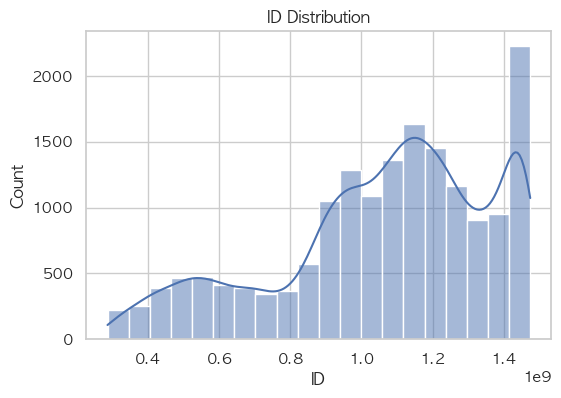

============= ID distribution =============
count    1.700700e+04
mean     1.059614e+09
std      2.999676e+08
min      2.849214e+08
25%      8.996543e+08
50%      1.112286e+09
75%      1.286983e+09
max      1.475077e+09
Name: ID, dtype: float64 



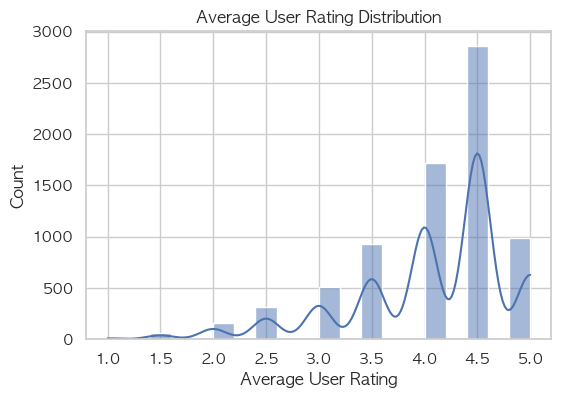

============= Average User Rating distribution =============
count    7561.000000
mean        4.060905
std         0.751428
min         1.000000
25%         3.500000
50%         4.500000
75%         4.500000
max         5.000000
Name: Average User Rating, dtype: float64 



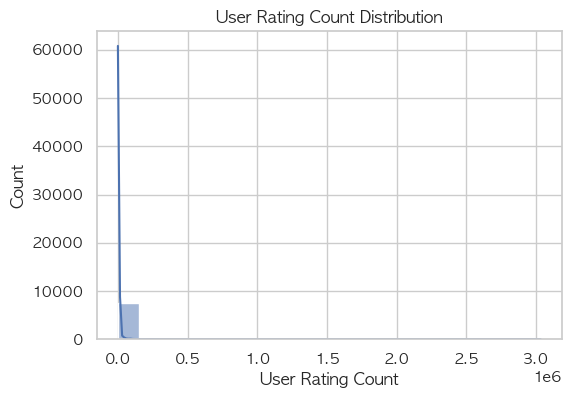

============= User Rating Count distribution =============
count    7.561000e+03
mean     3.306531e+03
std      4.232256e+04
min      5.000000e+00
25%      1.200000e+01
50%      4.600000e+01
75%      3.090000e+02
max      3.032734e+06
Name: User Rating Count, dtype: float64 



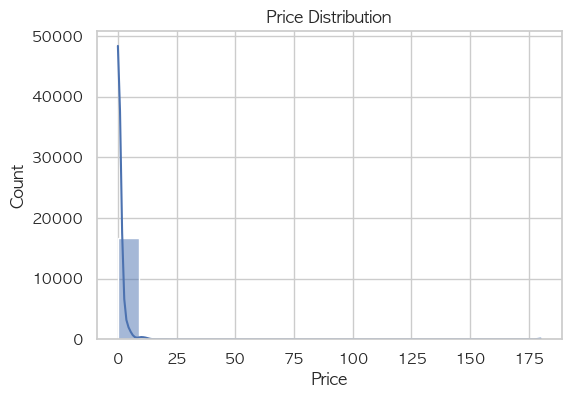

============= Price distribution =============
count    16983.000000
mean         0.813419
std          7.835732
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        179.990000
Name: Price, dtype: float64 



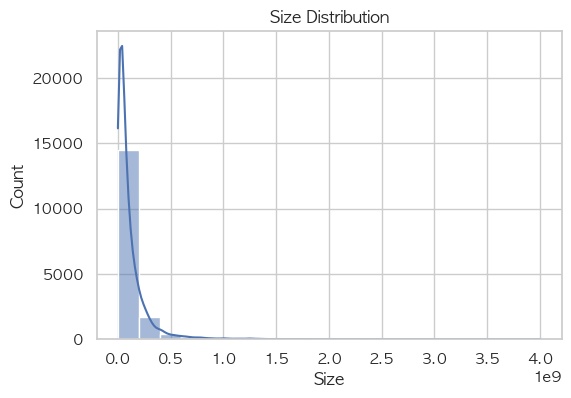

============= Size distribution =============
count    1.700600e+04
mean     1.157064e+08
std      2.036477e+08
min      5.132800e+04
25%      2.295014e+07
50%      5.676895e+07
75%      1.330271e+08
max      4.005591e+09
Name: Size, dtype: float64 



In [8]:
# 숫자형 변수의 고유값과 빈도 확인
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"{col} Distribution")
    plt.show()
    print(f"============= {col} distribution =============")
    print(df[col].describe(), "\n")

### primary genre 가 games가 아닌 데이터만 체크 : 별거없는듯?

In [9]:
df_no_games = df[df['Primary Genre'] != 'Games']
df_no_games.head()

,ID,Name,Subtitle,Icon URL,Average User Rating,User Rating Count,Price,In-app Purchases,Description,Developer,Age Rating,Languages,Size,Primary Genre,Genres,Original Release Date,Current Version Release Date
21,291723451,All You Can Eat,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purpl...,2.0,30.0,0.99,NaN,"""'All You Can Eat' is a very enjoyable game. I...",Armin Heinrich,9+,EN,4341760.0,Entertainment,"Entertainment, Games, Casual, Strategy",2008-09-24,2019-03-16
112,318280645,Age of Conquest: Europe,European Conquest,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,3.5,267.0,3.99,NaN,"""European Conquest for iPad, iPhone and iPod T...",Noble Master LLC,12+,EN,39074816.0,Entertainment,"Entertainment, Games, Board, Strategy",2009-06-16,2018-10-12
138,324331173,Stock Wars - Virtual Investing,NaN,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.5,3015.0,0.00,1.99,"""Stock Wars puts you in the fast paced world o...",Continuous Integration Inc.,4+,EN,10139648.0,Finance,"Finance, Simulation, Games, Strategy",2009-10-29,2017-11-28
155,328415391,Yahoo Fantasy Football & more,Fantasy games for everyone,https://is3-ssl.mzstatic.com/image/thumb/Purpl...,3.5,199585.0,0.00,NaN,"""The best in Fantasy Football, Baseball, Baske...",Yahoo,17+,"AR, BN, BG, CA, HR, CS, DA, NL, EN, ET, FI, FR...",145777664.0,Sports,"Sports, Games, Sports, Strategy",2009-09-08,2019-07-27
165,331513453,IpickMega,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purpl...,NaN,NaN,0.99,NaN,IpickMega delivers four separate random number...,"Avruk, LLC",4+,EN,1612800.0,Entertainment,"Entertainment, Casino, Games, Strategy",2009-09-23,2017-02-16


In [10]:
del df_no_games
gc.collect()

8370

### In-app 확인

In [11]:
print(df['In-app Purchases'].info())

print(df['In-app Purchases'].isnull().sum())

print(df['In-app Purchases'].notna().head())

<class 'pandas.Series'>
RangeIndex: 17007 entries, 0 to 17006
Series name: In-app Purchases
Non-Null Count  Dtype
--------------  -----
7683 non-null   str  
dtypes: str(1)
memory usage: 133.0 KB
None
9324
0    False
1    False
2    False
3    False
4    False
Name: In-app Purchases, dtype: bool


In [12]:
# 1. 쉼표를 기준으로 리스트로 쪼개기 (양옆 공백 제거)
exploded = df['In-app Purchases'].dropna().str.split(',').explode().str.strip()

# 2. 숫자로 변환 시도 (숫자가 아닌 'NaN', 'Null', 빈 문자열 등은 모두 NaN으로 바뀜)
numeric_converted = pd.to_numeric(exploded, errors='coerce')

# 3. 변환에 실패한(NaN이 된) 원래의 값들만 확인해보기
anomalies = exploded[numeric_converted.isna()].unique()

print("============= 발견된 이상치/결측치 문자열 =============")
print(anomalies)

============= 발견된 이상치/결측치 문자열 =============
<StringArray>
[]
Length: 0, dtype: str


In [13]:
(df['In-app Purchases']=='0.0').sum()

np.int64(0)

### Languages 확인

In [14]:
# 1. 쉼표(,)를 기준으로 언어들을 쪼개 리스트로 만듭니다.
# 2. .explode()를 사용해 리스트 안의 언어들을 각각 독립된 행으로 펼칩니다.
# 3. .str.strip()으로 혹시 모를 앞뒤 공백(예: ' ZH' -> 'ZH')을 제거합니다.
# 4. value_counts()로 개수를 세고, .head(5)로 상위 5개만 출력합니다.

top_5_languages = df['Languages'].str.split(',').explode().str.strip().value_counts().head(5)
print(top_5_languages)

Languages
EN    16834
ZH     4989
DE     2599
FR     2526
ES     2420
Name: count, dtype: int64


In [15]:
# # 결측치가 있으면 에러가 날 수 있으므로 미리 빈 문자열 등으로 채워두거나 처리해야 합니다.
# df_lang = df.copy()
# df_lang['Languages'] = df_lang['Languages'].fillna('')

# # 알파벳 순으로 정렬하여 다시 콤마로 합치는 함수
# def sort_languages(lang_str):
#     if not lang_str:
#         return lang_str
#     # 1. 콤마로 쪼개고 공백 제거: ['FR', 'EN']
#     lang_list = [x.strip() for x in lang_str.split(',')]
#     # 2. 알파벳 순 정렬: ['EN', 'FR']
#     lang_list.sort()
#     # 3. 다시 콤마로 연결: 'EN, FR'
#     return ', '.join(lang_list)

# # 데이터프레임에 적용
# df_lang['Languages_Sorted'] = df_lang['Languages'].apply(sort_languages)

# # [확인] 이제 EN, FR과 FR, EN이 'EN, FR'로 통일되어 하나로 집계됩니다!
# print(df_lang['Languages_Sorted'].value_counts().head(10))

## Preprocessing

In [16]:
df['Subtitle'] = df['Subtitle'].fillna('')

print("결측치 개수:", df['Subtitle'].isnull().sum())

결측치 개수: 0


In [17]:
df['Price'] = df['Price'].fillna(0)

print("결측치 개수:", df['Price'].isnull().sum())

결측치 개수: 0


In [18]:
# mode()[0]을 하면 최빈값인 'EN' 문자열을 쏙 뽑아옵니다.
most_frequent_lang = df['Languages'].mode()[0]

# 결측치(NaN)를 'EN'으로 채우기
df['Languages'] = df['Languages'].fillna(most_frequent_lang)

# 잘 채워졌는지 결측치 개수 확인 (0이 나와야 합니다)
print("결측치 개수:", df['Languages'].isnull().sum())

결측치 개수: 0


In [19]:
df.dropna(subset='Size', inplace=True)

print("결측치 개수:", df['Size'].isnull().sum())

결측치 개수: 0


### User Rating 카테고리화 변수 추가

In [20]:
# # 1. 데이터 타입을 문자열로 변환
# df['User_Rating_Cat'] = df['Average User Rating'].astype(str)

# # 2. 실제 데이터 범위인 1.0부터 5.0까지 0.5 단위로 리스트 생성
# # np.arange(1.0, 5.5, 0.5) 결과: [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
# rating_order = [f"{x:.1f}" for x in np.arange(1.0, 5.5, 0.5)]

# # 3. 카테고리 형식 지정
# df['User_Rating_Cat'] = pd.Categorical(df['User_Rating_Cat'], categories=rating_order, ordered=True)

In [21]:
# # 구간(Bins)과 라벨 정의
# # 1.0~3.5 미만(저평가), 3.5~4.5 미만(평범), 4.5~5.0(고평가)
# bins = [1.0, 3.5, 4.5, 5.1]  # 오른쪽 경계 포함을 위해 마지막은 5.1
# labels = ['Low (1.0-3.0)', 'Average (3.5-4.0)', 'High (4.5-5.0)']

# df['Rating_Group'] = pd.cut(df['Average User Rating'], bins=bins, labels=labels, right=False)

# # 잘 나눠졌는지 확인
# print(df['Rating_Group'].value_counts().sort_index())

## 전처리 결과

- Subtitle : 결측치 공백('')으로 채움

- price : 결측치 최빈값(0)으로 채움

- Languages : 결측치 최빈값(EN)으로 채움

- Size : 결측치 drop

## Feature Engineering

### Subtitle 유무

In [22]:
# # 1차
# df['Has_Subtitle'] = df['Subtitle'].notnull().astype(int)
# # 2차
# df['Has_Subtitle'] = (df['Subtitle'] != '').astype(int)
# 최종
df['Has_Subtitle'] = (df['Subtitle'].fillna('').str.strip() != '').astype(int)

### 유료게임/무료게임 여부

In [23]:
df['Price_Type'] = np.where(df['Price'] == 0, 'Free', 'Paid')

### 지원 언어 갯수

In [24]:
df['Languages_Counts'] = df['Languages'].str.split(',').str.len()

### 사이즈 변환

In [25]:
df['Size_MB'] = round(df['Size']/(1024*1024), 2)

### 앱 유지보수 기간

In [26]:
df['Maintenance_Term'] = (df['Current Version Release Date'] - df['Original Release Date']).dt.days

### In-app 관련 파생변수

In [27]:
# 인앱결제유무
df['Has_IAP'] = df['In-app Purchases'].notnull().astype(int)

# 인앱결제 상품 갯수
df['IAP_Counts'] = df['In-app Purchases'].str.split(',').str.len()

# 인앱결제 최소, 최대, 평균가격
# 1. 계산을 위해 결측치(NaN)를 빈 문자열('')로 대체하고 쉼표로 분리합니다.
prices_split = df['In-app Purchases'].fillna('').str.split(',')

# 2. 문자열 리스트를 숫자(float) 리스트로 변환하는 함수 정의
def to_float_list(x):
    # 빈 문자열이거나 빈 리스트인 경우 None 반환
    if not x or x == ['']:
        return []
    try:
        return [float(i.strip()) for i in x]
    except:
        return []

# 3. 숫자 리스트 칼럼을 임시로 생성
df['Inapp_Price_List'] = prices_split.apply(to_float_list)

# 4. 최대, 최소, 평균 파생변수 생성 (빈 리스트인 경우는 NaN 처리)
df['IAP_Max'] = df['Inapp_Price_List'].apply(lambda x: max(x) if x else np.nan)
df['IAP_Min'] = df['Inapp_Price_List'].apply(lambda x: min(x) if x else np.nan)
df['IAP_Mean'] = df['Inapp_Price_List'].apply(lambda x: np.mean(x) if x else np.nan)

# 5. 임시로 만든 리스트 칼럼 삭제
df.drop(columns=['Inapp_Price_List'], inplace=True)

### Genres

In [28]:
df['Genre_Counts'] = df['Genres'].apply(lambda x: len([g.strip() for g in str(x).split(',') if g.strip()]))

In [29]:
contains_games = df['Genres'].str.contains('Games', case=False, na=False)
contains_strategy = df['Genres'].str.contains('Strategy', case=False, na=False)

# 1. 'Games'가 포함되지 않은 행 (NOT 조건)
no_games_df = df[~contains_games]
count_no_games = len(no_games_df)

# 2. 'Strategy'가 포함되지 않은 행 (NOT 조건)
no_strategy_df = df[~contains_strategy]
count_no_strategy = len(no_strategy_df)

# 3. 'Games'와 'Strategy' 둘 다 포함되지 않은 행 (OR 결과를 NOT 반전)
#    또는 (~contains_games & ~contains_strategy) 로 표현해도 같습니다.
neither_df = df[~(contains_games | contains_strategy)]
count_neither = len(neither_df)


# --- 결과 출력 ---
print("--- [전체 데이터 확인] ---")
print(df[['ID', 'Genres', 'Genre_Counts']])
print("\n" + "="*50 + "\n")

print(f"1. 'Games'가 포함되지 않은 행의 개수: {count_no_games}개")
print(no_games_df[['ID', 'Genres']])
print("-" * 50)

print(f"2. 'Strategy'가 포함되지 않은 행의 개수: {count_no_strategy}개")
print(no_strategy_df[['ID', 'Genres']])
print("-" * 50)

print(f"3. 'Games'와 'Strategy' 둘 다 포함되지 않은 행의 개수: {count_neither}개")
print(neither_df[['ID', 'Genres']])

--- [전체 데이터 확인] ---
               ID                                  Genres  Genre_Counts
0       284921427                 Games, Strategy, Puzzle             3
1       284926400                  Games, Strategy, Board             3
2       284946595                  Games, Board, Strategy             3
3       285755462                 Games, Strategy, Puzzle             3
4       285831220       Games, Strategy, Board, Education             4
...           ...                                     ...           ...
17002  1474626442  Games, Entertainment, Casual, Strategy             4
17003  1474919257                 Games, Family, Strategy             3
17004  1474962324                         Games, Strategy             2
17005  1474963671                 Games, Strategy, Action             3
17006  1475076711                 Games, Strategy, Puzzle             3

[17006 rows x 3 columns]


1. 'Games'가 포함되지 않은 행의 개수: 0개
Empty DataFrame
Columns: [ID, Genres]
Index: []
----------

In [30]:
df['Release_Year'] = df['Original Release Date'].dt.year
df['Release_Month'] = df['Original Release Date'].dt.month

### FI 결과

13개 파생변수 생성

In [31]:
print(df.shape)

df.isnull().sum()

(17006, 30)


ID                                 0
Name                               0
Subtitle                           0
Icon URL                           0
Average User Rating             9445
User Rating Count               9445
Price                              0
In-app Purchases                9324
Description                        0
Developer                          0
Age Rating                         0
Languages                          0
Size                               0
Primary Genre                      0
Genres                             0
Original Release Date              0
Current Version Release Date       0
Has_Subtitle                       0
Price_Type                         0
Languages_Counts                   0
Size_MB                            0
Maintenance_Term                   0
Has_IAP                            0
IAP_Counts                      9324
IAP_Max                         9324
IAP_Min                         9324
IAP_Mean                        9324
G

## 리뷰 유무로 데이터 분리해서 비교 분석

In [32]:
# 1. 유저 평가가 존재하는 데이터셋 (결측치가 아닌 데이터)
df_with_ratings = df[df['Average User Rating'].notna()].copy()

# 2. 유저 평가가 존재하지 않는 데이터셋 (결측치인 데이터)
df_without_ratings = df[df['Average User Rating'].isnull()].copy()

# 분리가 잘 되었는지 데이터 수 확인
print(f"전체 데이터 shape: {df.shape}")
print(f"유저 평가 존재 데이터 shape: {df_with_ratings.shape} (예상: 7561 rows)")
print(f"유저 평가 없음 데이터 shpae: {df_without_ratings.shape} (예상: {len(df) - 7561} rows)")

전체 데이터 shape: (17006, 30)
유저 평가 존재 데이터 shape: (7561, 30) (예상: 7561 rows)
유저 평가 없음 데이터 shpae: (9445, 30) (예상: 9445 rows)


In [33]:
# 시각화를 위해 'Group' 라벨 부여 후 통합
df_with_ratings['Group'] = 'Active (리뷰 O)'
df_without_ratings['Group'] = 'Ghost (리뷰 X)'
df_viz = pd.concat([df_with_ratings, df_without_ratings], ignore_index=True)

# 데이터가 정상적으로 합쳐졌는지 확인
print(f"Active 그룹 데이터 수: {len(df_with_ratings)}")
print(f"Ghost 그룹 데이터 수: {len(df_without_ratings)}")
print(f"합쳐진 df_viz 총 데이터 수: {len(df_viz)}")

Active 그룹 데이터 수: 7561
Ghost 그룹 데이터 수: 9445
합쳐진 df_viz 총 데이터 수: 17006


### 장르

In [34]:
# 원본 데이터 카피
df_genres = df_with_ratings.copy()

# 1. 문자열을 콤마(와 공백) 기준으로 나누어 '리스트'로 변환
# 정규표현식 ',\s*'은 쉼표 뒤에 공백이 있든 없든 다 잘라줍니다.
df_genres['Genre_List'] = df_genres['Genres'].str.split(',\s*')

# 2. 리스트의 요소들을 개별 행으로 확장 (Explode)
df_exploded = df_genres.explode('Genre_List')

# [확인] 이제 각 장르가 개별 행으로 분리되어 정확한 빈도수 계산 가능!
print("--- 진짜 장르별 개수 ---")
print(df_exploded['Genre_List'].value_counts().head(10))

# [활용] 장르별 평균 평점 구하기
df_rating_exploded = df_with_ratings.copy()
df_rating_exploded['Genre_List'] = df_rating_exploded['Genres'].str.split(',\s*')
df_rating_exploded = df_rating_exploded.explode('Genre_List')
print(df_rating_exploded.groupby('Genre_List')['Average User Rating'].mean().sort_values(ascending=False))

--- 진짜 장르별 개수 ---
Genre_List
Games            7561
Strategy         7560
Entertainment    3725
Puzzle           1368
Simulation       1246
Action           1025
Board             857
Role Playing      796
Casual            527
Card              367
Name: count, dtype: int64
Genre_List
Magazines & Newspapers    5.000000
Shopping                  4.500000
Health & Fitness          4.333333
Photo & Video             4.300000
Emoji & Expressions       4.250000
News                      4.222222
Travel                    4.216216
Casual                    4.203985
Lifestyle                 4.197531
Food & Drink              4.180000
Music                     4.180000
Casino                    4.148148
Social Networking         4.144737
Puzzle                    4.135965
Family                    4.127517
Action                    4.107317
Role Playing              4.096734
Navigation                4.083333
Education                 4.076786
Games                     4.060905
Strategy      

,Genre,Ratio (%)
0,Entertainment,49.265970
1,Puzzle,18.092845
2,Simulation,16.479302


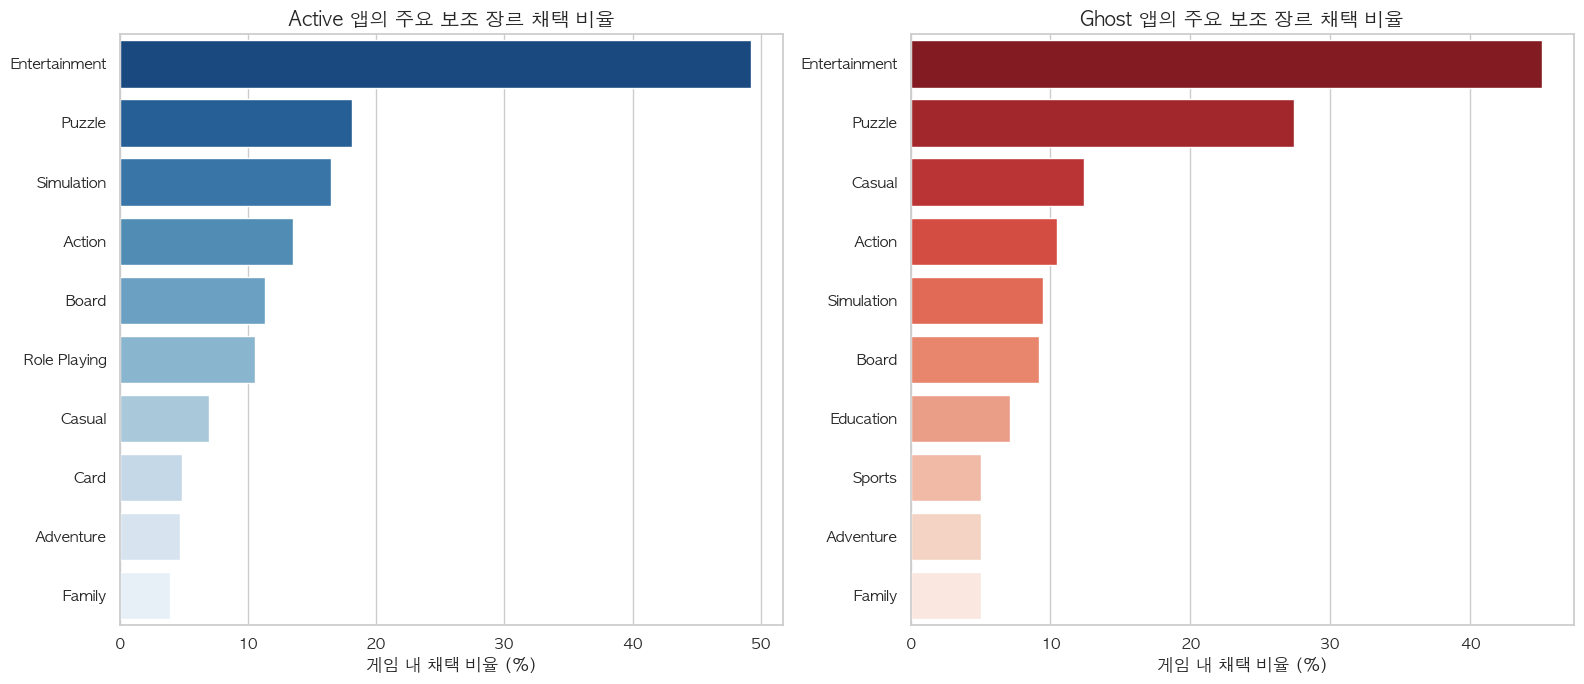

In [35]:
# 1. 기본 장르 제외 및 보조 장르 리스트 생성
stop_genres = ['Games', 'Strategy']

def get_sub_genres(genre_str):
    if pd.isna(genre_str): 
        return []
    # 쉼표로 분리하고 공백 제거
    genres = [g.strip() for g in str(genre_str).split(',')]
    # stop_genres에 포함되지 않는 실질적 보조 장르만 필터링
    return [g for g in genres if g not in stop_genres]

# 보조 장르 리스트 칼럼 및 개수 칼럼(Sub_Genre_Counts) 생성
df_viz['Sub_Genres'] = df_viz['Genres'].apply(get_sub_genres)
df_viz['Sub_Genre_Counts'] = df_viz['Sub_Genres'].apply(len)

# 2. 행 확장(Explode)을 통한 장르별 데이터 분리
df_exploded = df_viz.explode('Sub_Genres')
df_exploded = df_exploded.dropna(subset=['Sub_Genres']) # 빈 값 제거

# 3. 그룹별 전체 게임 수 대비 특정 보조 장르 채택 비율(%) 계산 함수 (수정본)
def get_top_genres_ratio(group_name, top_n=10):
    # 해당 그룹의 전체 게임(앱) 개수 확인
    group_data = df_viz[df_viz['Group'] == group_name]
    total_games = len(group_data)
    
    # 만약 데이터가 0개라면 경고 메시지 출력 (이전 Group 전처리 확인용)
    if total_games == 0:
        print(f"⚠️ 경고: '{group_name}' 그룹의 데이터가 0개입니다. 이전 단계의 df_viz 데이터를 확인해주세요.")
        return pd.DataFrame(columns=['Genre', 'Ratio (%)'])
    
    # 해당 그룹의 보조 장르별 등장 횟수
    sub_genre_counts = df_exploded[df_exploded['Group'] == group_name]['Sub_Genres'].value_counts().head(top_n)
    
    # Pandas 버전에 의존하지 않고 명시적으로 깔끔하게 DataFrame 생성
    df_ratio = pd.DataFrame({
        'Genre': sub_genre_counts.index,
        'Ratio (%)': (sub_genre_counts.values / total_games) * 100
    })
    
    return df_ratio

# 함수 다시 적용
active_top10 = get_top_genres_ratio('Active (리뷰 O)')
ghost_top10 = get_top_genres_ratio('Ghost (리뷰 X)')

# 데이터가 잘 만들어졌는지 시각화 전에 눈으로 먼저 확인 (디버깅 습관)
display(active_top10.head(3))

# 4. 시각화 코드는 기존과 동일하게 실행
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=active_top10, y='Genre', x='Ratio (%)', palette='Blues_r', ax=axes[0])
axes[0].set_title('Active 앱의 주요 보조 장르 채택 비율', fontsize=14, fontweight='bold')
axes[0].set_xlabel('게임 내 채택 비율 (%)')
axes[0].set_ylabel('')

sns.barplot(data=ghost_top10, y='Genre', x='Ratio (%)', palette='Reds_r', ax=axes[1])
axes[1].set_title('Ghost 앱의 주요 보조 장르 채택 비율', fontsize=14, fontweight='bold')
axes[1].set_xlabel('게임 내 채택 비율 (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

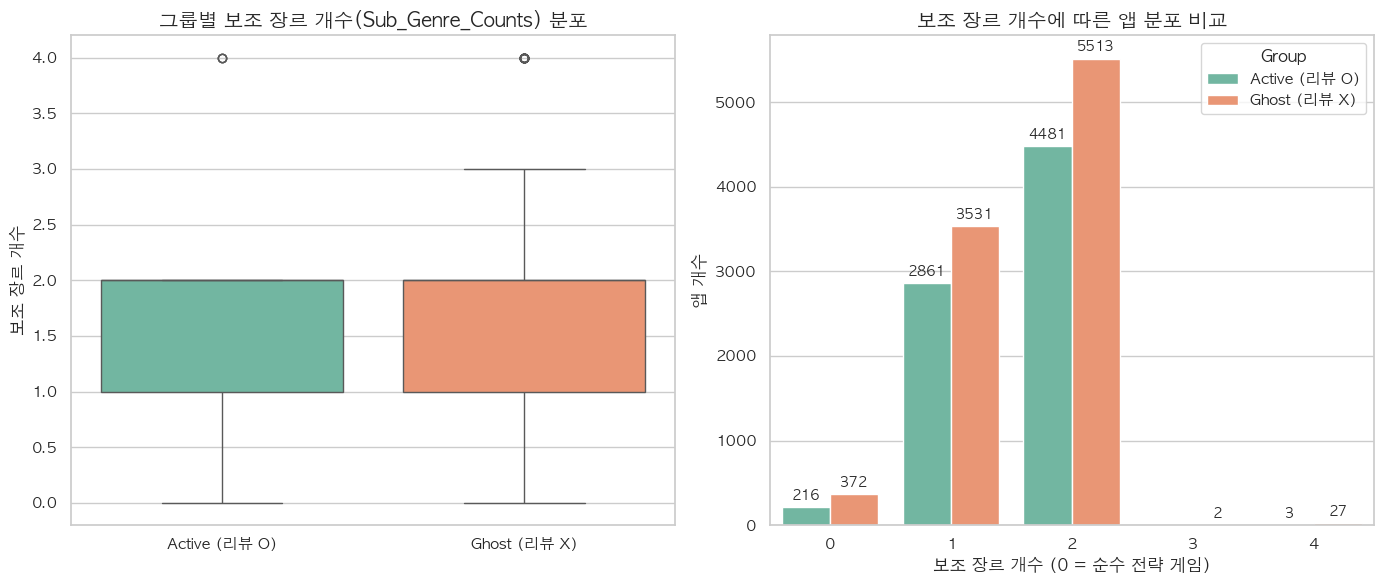

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌측: 그룹별 보조 장르 개수(Sub_Genre_Counts) 분포 (Boxplot)
sns.boxplot(data=df_viz, x='Group', y='Sub_Genre_Counts', palette='Set2', ax=axes[0])
axes[0].set_title('그룹별 보조 장르 개수(Sub_Genre_Counts) 분포', fontsize=14, fontweight='bold')
axes[0].set_ylabel('보조 장르 개수')
axes[0].set_xlabel('')

# 우측: 장르 개수별 앱의 비율 구성 (Countplot 형태)
sns.countplot(data=df_viz, x='Sub_Genre_Counts', hue='Group', palette='Set2', ax=axes[1])
axes[1].set_title('보조 장르 개수에 따른 앱 분포 비교', fontsize=14, fontweight='bold')
axes[1].set_ylabel('앱 개수')
axes[1].set_xlabel('보조 장르 개수 (0 = 순수 전략 게임)')
# 막대 그래프 위에 수치 표시
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fontsize=10, fmt='%d')

plt.tight_layout()
plt.show()

#### 장르 심화

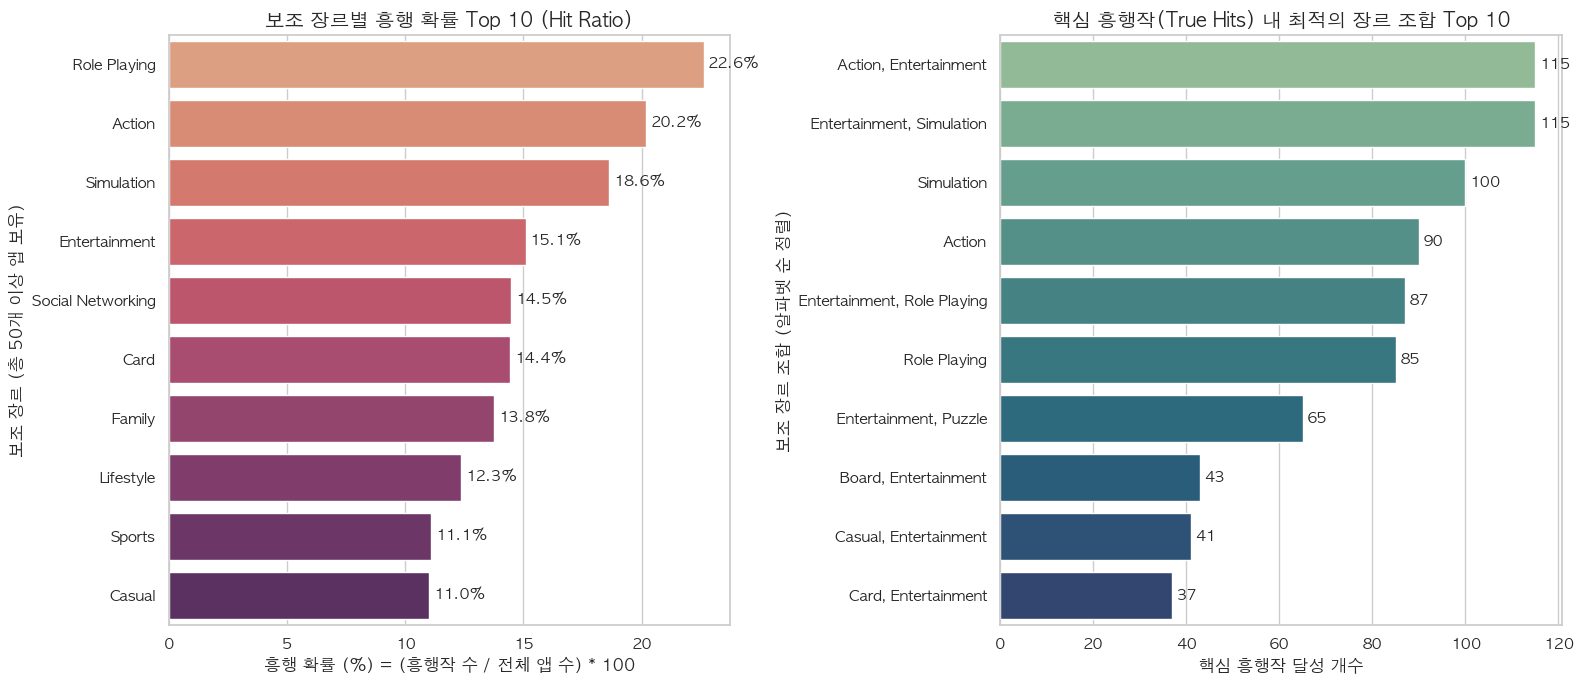

In [ ]:
# 1. '핵심 흥행작(True Hits)' 정의 (평점 4.5 이상 & 리뷰 수 상위 20%)
top_20_count = df_with_ratings['User Rating Count'].quantile(0.8)
df_with_ratings['Is_True_Hit'] = (df_with_ratings['Average User Rating'] >= 4.5) & \
                                 (df_with_ratings['User Rating Count'] >= top_20_count)

# 2. 보조 장르 추출 함수 (Games, Strategy 제외)
stop_genres = ['Games', 'Strategy']

def get_sub_genres(genre_str):
    if pd.isna(genre_str): return []
    genres = [g.strip() for g in str(genre_str).split(',')]
    return [g for g in genres if g not in stop_genres]

df_with_ratings['Sub_Genres'] = df_with_ratings['Genres'].apply(get_sub_genres)

# 3. 보조 장르별 데이터 분리 (Explode)
df_exploded = df_with_ratings.explode('Sub_Genres')
df_exploded = df_exploded.dropna(subset=['Sub_Genres'])

# [핵심 로직 1] 통계적 노이즈 제거: 전체 앱 수가 50개 미만인 마이너 장르 필터링
genre_totals = df_exploded['Sub_Genres'].value_counts()
valid_genres = genre_totals[genre_totals >= 50].index
df_valid_exploded = df_exploded[df_exploded['Sub_Genres'].isin(valid_genres)]

# [핵심 로직 2] 보조 장르별 흥행 확률(Hit Ratio) 계산
total_per_genre = df_valid_exploded['Sub_Genres'].value_counts()
hits_per_genre = df_valid_exploded[df_valid_exploded['Is_True_Hit']]['Sub_Genres'].value_counts()

# Pandas 버전에 관계없이 안전하게 데이터프레임 병합
hit_ratio_df = pd.DataFrame({
    'Total_Apps': total_per_genre,
    'Hit_Apps': hits_per_genre
}).fillna(0) # 흥행작이 하나도 없는 장르는 0으로 채움

hit_ratio_df['Hit_Ratio (%)'] = (hit_ratio_df['Hit_Apps'] / hit_ratio_df['Total_Apps']) * 100

# 상위 10개 흥행 확률 장르 추출
top10_hit_ratio_raw = hit_ratio_df.sort_values(by='Hit_Ratio (%)', ascending=False).head(10)
top10_hit_ratio = pd.DataFrame({
    'Genre': top10_hit_ratio_raw.index, 
    'Hit_Ratio (%)': top10_hit_ratio_raw['Hit_Ratio (%)'].values
})

# [핵심 로직 3] 핵심 흥행작 내 장르 조합(Combination) 시너지 분석
def get_genre_combination(sub_genres_list):
    # 보조 장르가 아예 없는 경우는 제외 처리용 라벨링
    if not sub_genres_list: return 'Pure Strategy (No Sub)'
    # 순서가 달라도 같은 조합으로 인식하도록 알파벳 순 정렬 후 결합
    sorted_genres = sorted(sub_genres_list)
    return ', '.join(sorted_genres)

# 흥행작(True Hits) 데이터만 필터링
true_hits_df = df_with_ratings[df_with_ratings['Is_True_Hit']].copy()
true_hits_df['Genre_Combination'] = true_hits_df['Sub_Genres'].apply(get_genre_combination)

# 순수 전략 게임 제외 및 Top 10 조합 추출
combinations = true_hits_df[true_hits_df['Genre_Combination'] != 'Pure Strategy (No Sub)']
top10_combinations_raw = combinations['Genre_Combination'].value_counts().head(10)
top10_combinations = pd.DataFrame({
    'Combination': top10_combinations_raw.index, 
    'Hit_Count': top10_combinations_raw.values
})

# 4. 시각화 (1x2 서브플롯)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 좌측: 보조 장르별 흥행 확률 (막대그래프)
sns.barplot(data=top10_hit_ratio, y='Genre', x='Hit_Ratio (%)', palette='flare', ax=axes[0])
axes[0].set_title('보조 장르별 흥행 확률 Top 10 (Hit Ratio)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('흥행 확률 (%) = (흥행작 수 / 전체 앱 수) * 100')
axes[0].set_ylabel('보조 장르 (총 50개 이상 앱 보유 장르 대상)')

# 막대 끝에 확률 숫자 표시
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fmt='%.1f%%', fontsize=11)

# 우측: 핵심 흥행작의 주요 장르 조합 (막대그래프)
sns.barplot(data=top10_combinations, y='Combination', x='Hit_Count', palette='crest', ax=axes[1])
axes[1].set_title('핵심 흥행작(True Hits) 내 최적의 장르 조합 Top 10', fontsize=14, fontweight='bold')
axes[1].set_xlabel('핵심 흥행작 달성 개수')
axes[1].set_ylabel('보조 장르 조합 (알파벳 순 정렬)')

for container in axes[1].containers:
    axes[1].bar_label(container, padding=3, fmt='%d', fontsize=11)

plt.tight_layout()
plt.show()

### Price

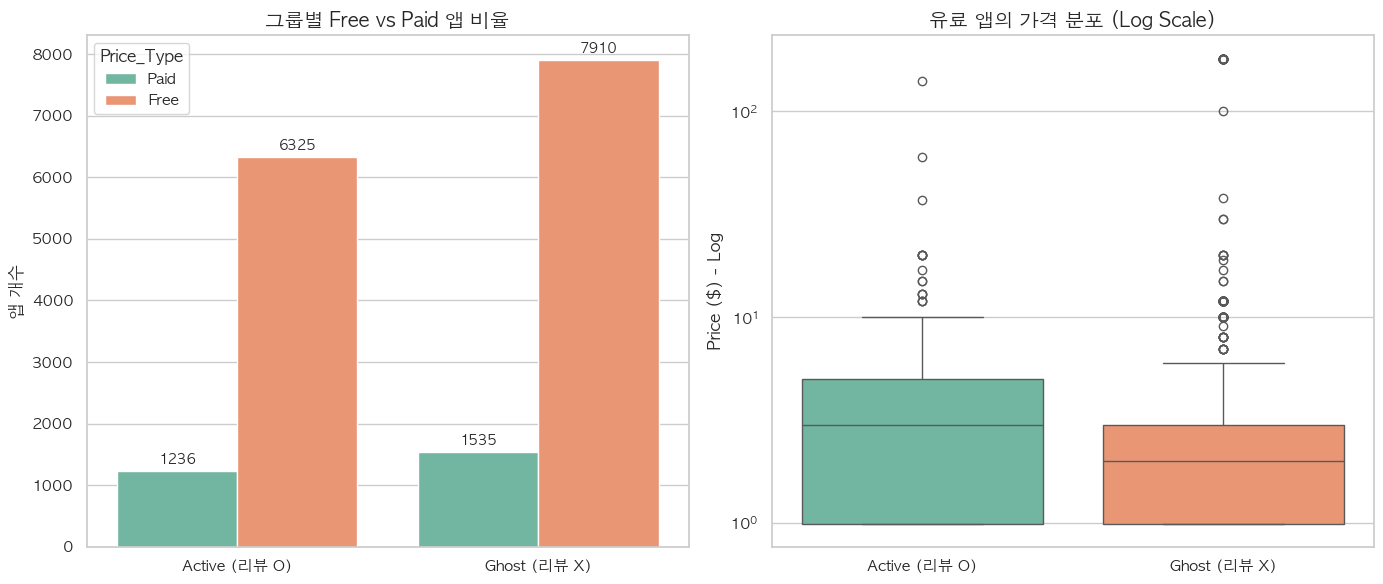

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌측: 유무료(Price_Type) 비율 비교 (누적 막대 그래프 대신 100% 기준 비율로 보여주기 위해 카운트 플롯 사용)
sns.countplot(data=df_viz, x='Group', hue='Price_Type', palette='Set2', ax=axes[0])
axes[0].set_title('그룹별 Free vs Paid 앱 비율', fontsize=14, fontweight='bold')
axes[0].set_ylabel('앱 개수')
axes[0].set_xlabel('')
# 막대 그래프 위에 수치 표시
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=10, fmt='%d')

# 우측: 유료 앱(Price > 0)의 가격 분포 비교 (Boxplot + 로그 스케일)
paid_apps = df_viz[df_viz['Price'] > 0]
sns.boxplot(data=paid_apps, x='Group', y='Price', palette='Set2', ax=axes[1])
axes[1].set_yscale('log') # 가격 스펙트럼이 넓으므로 로그 스케일 적용
axes[1].set_title('유료 앱의 가격 분포 (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($) - Log')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 인앱결제

In [38]:
# # 인앱결제가 존재하는 데이터만 필터링
# df_iap = df_viz[df_viz['Has_IAP'] == True].copy()

# fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# iap_cols = ['IAP_Min', 'IAP_Mean', 'IAP_Max']
# titles = ['최소 결제 금액 분포', '평균 결제 금액 분포', '최대 결제 금액 분포']

# for i, col in enumerate(iap_cols):
#     sns.boxplot(data=df_iap, x='Group', y=col, palette='Pastel1', ax=axes[i], showfliers=False) 
#     # showfliers=False : 과도한 극단치(고래 유저용 결제)를 제외하고 박스플롯의 몸통(분포)을 명확히 보기 위함
#     axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
#     axes[i].set_ylabel('Price ($)')
#     axes[i].set_xlabel('')

# plt.tight_layout()
# plt.show()

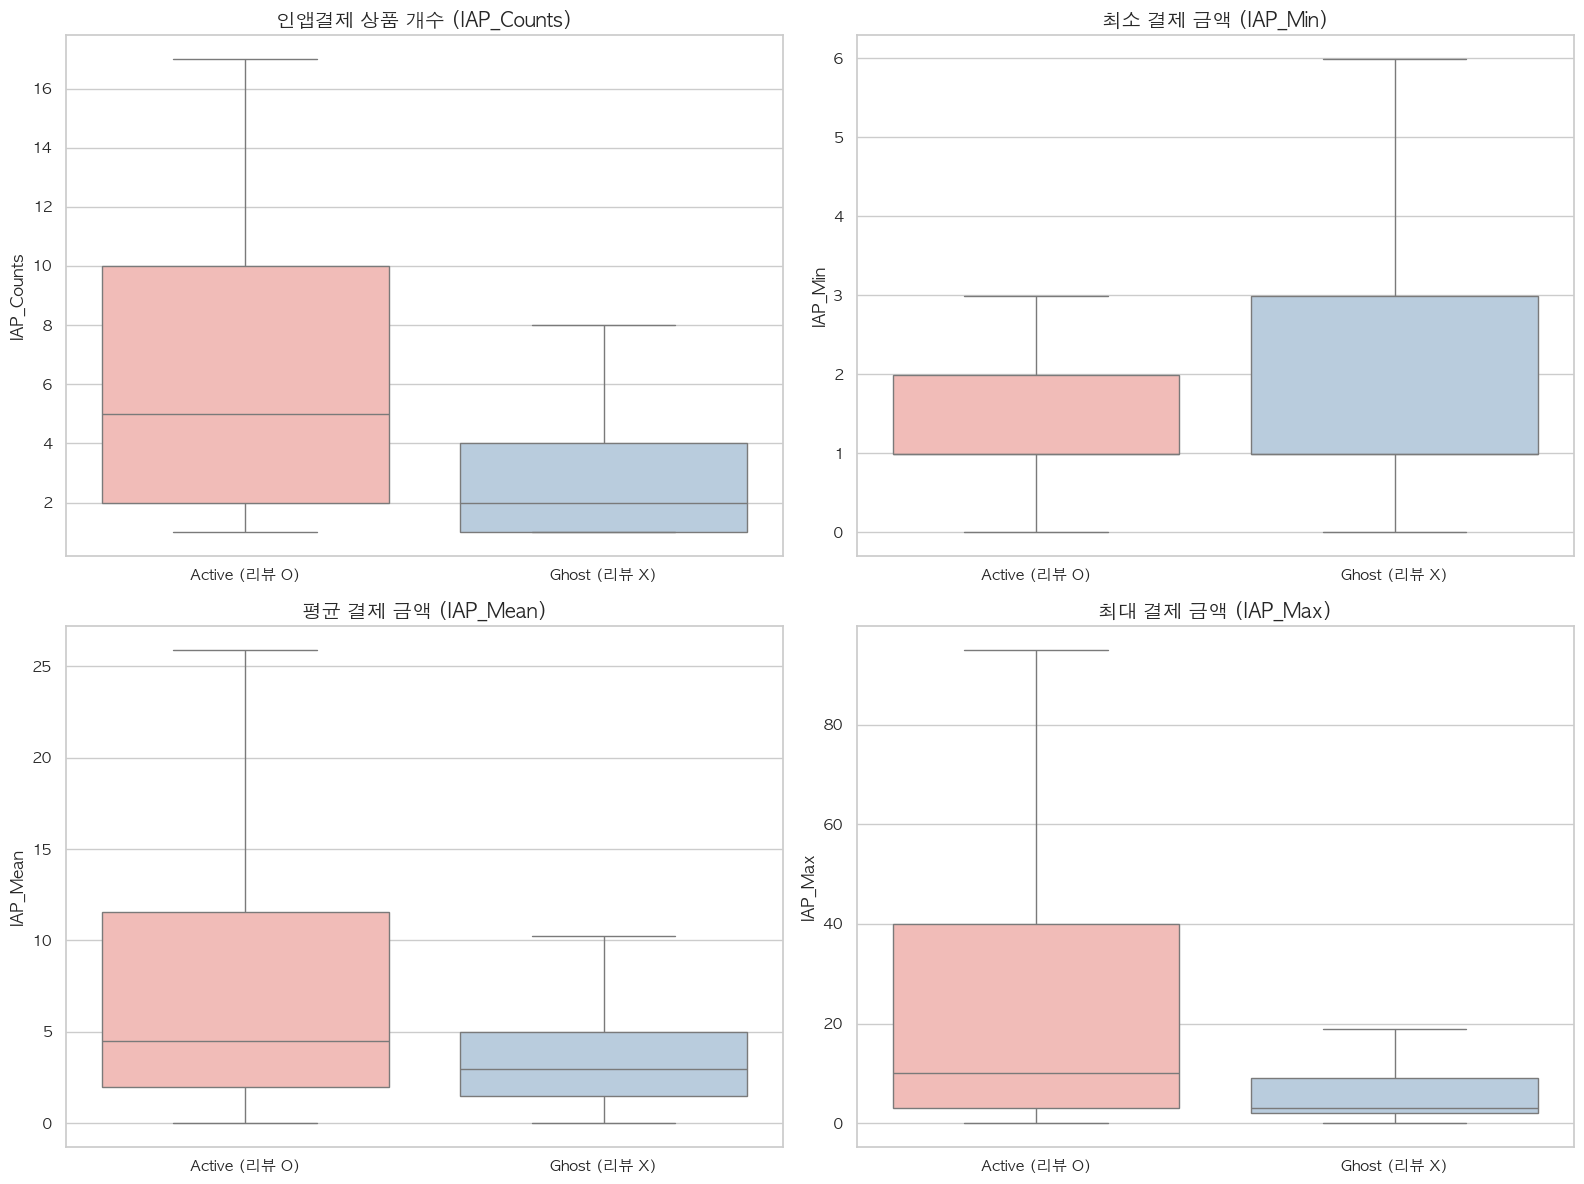

In [39]:
# 인앱결제가 존재하는 데이터만 필터링
df_iap = df_viz[df_viz['Has_IAP'] == True].copy()

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # 2D 배열을 1D로 펴서 반복문 사용을 쉽게 만듦

iap_cols = ['IAP_Counts', 'IAP_Min', 'IAP_Mean', 'IAP_Max']
titles = ['인앱결제 상품 개수 (IAP_Counts)', '최소 결제 금액 (IAP_Min)', 
          '평균 결제 금액 (IAP_Mean)', '최대 결제 금액 (IAP_Max)']

for i, col in enumerate(iap_cols):
    sns.boxplot(data=df_iap, x='Group', y=col, palette='Pastel1', ax=axes[i], showfliers=False)
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

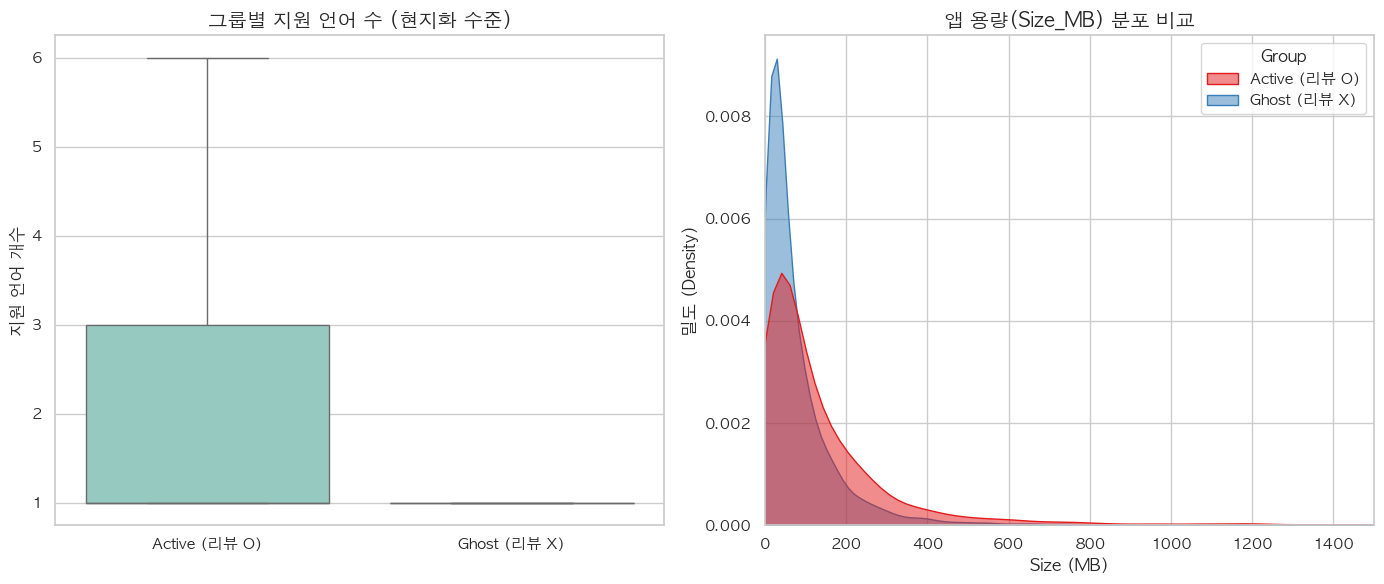

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌측: 지원 언어 수 비교 (Boxplot)
sns.boxplot(data=df_viz, x='Group', y='Languages_Counts', palette='Set3', ax=axes[0], showfliers=False)
axes[0].set_title('그룹별 지원 언어 수 (현지화 수준)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('지원 언어 개수')
axes[0].set_xlabel('')

# 우측: 앱 용량 분포 비교 (KDE Plot - 겹침 플롯)
sns.kdeplot(data=df_viz, x='Size_MB', hue='Group', fill=True, common_norm=False, alpha=0.5, palette='Set1', ax=axes[1])
axes[1].set_xlim(0, 1500) # 시각적 편의를 위해 1.5GB 이상 초고용량 꼬리 부분은 컷오프
axes[1].set_title('앱 용량(Size_MB) 분포 비교', fontsize=14, fontweight='bold')
axes[1].set_ylabel('밀도 (Density)')
axes[1].set_xlabel('Size (MB)')

plt.tight_layout()
plt.show()

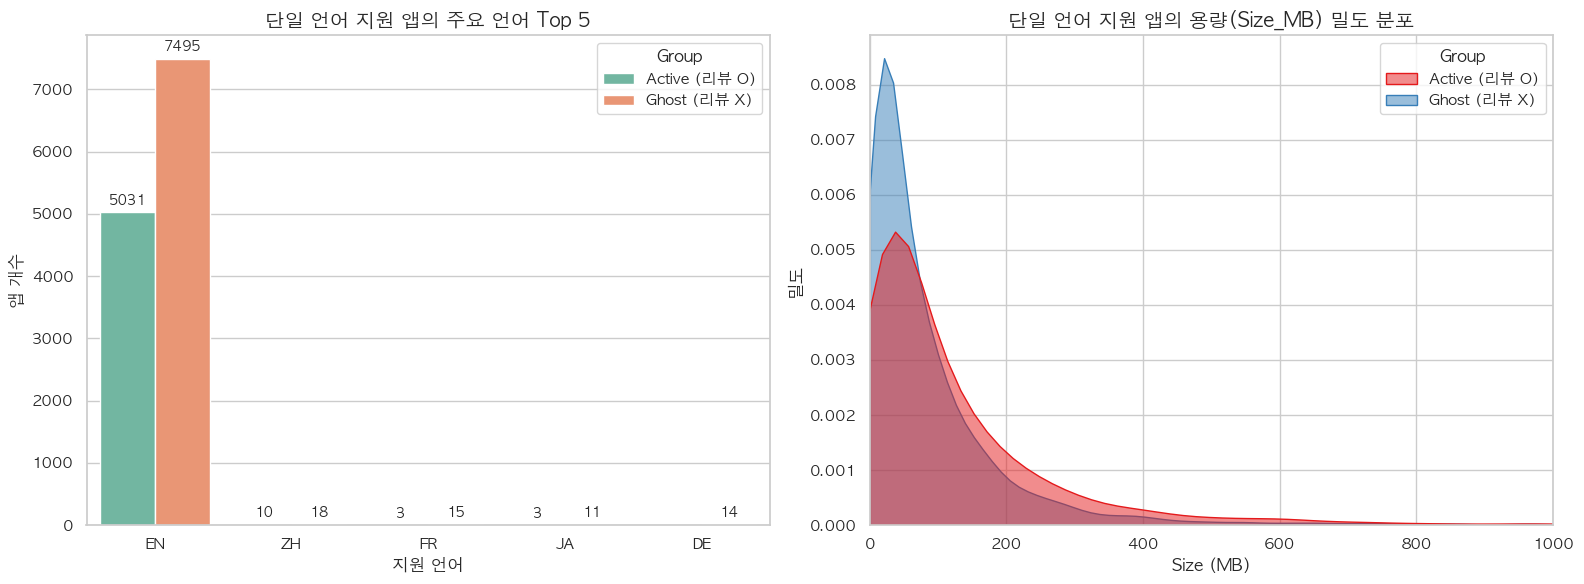

In [41]:
# '지원 언어가 1개'인 데이터만 추출 (단일 언어 앱)
df_single_lang = df_viz[df_viz['Languages_Counts'] == 1].copy()

# 단일 언어 앱들이 주로 지원하는 상위 5개 언어 추출
top_5_langs = df_single_lang['Languages'].value_counts().head(5).index
df_top_single_lang = df_single_lang[df_single_lang['Languages'].isin(top_5_langs)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 좌측: 단일 언어 앱의 지원 언어 종류 (카운트 플롯)
sns.countplot(data=df_top_single_lang, x='Languages', hue='Group', 
              order=top_5_langs, palette='Set2', ax=axes[0])
axes[0].set_title('단일 언어 지원 앱의 주요 언어 Top 5', fontsize=14, fontweight='bold')
axes[0].set_ylabel('앱 개수')
axes[0].set_xlabel('지원 언어')
# 막대 그래프 위에 수치 표시
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=10, fmt='%d')

# 우측: 단일 언어 앱들의 앱 용량(Size_MB) 분포 (KDE 플롯)
# (비교군: 1개 언어만 지원하는 Active 앱 vs Ghost 앱)
sns.kdeplot(data=df_single_lang, x='Size_MB', hue='Group', 
            fill=True, common_norm=False, alpha=0.5, palette='Set1', ax=axes[1])
axes[1].set_xlim(0, 1000) # 시각화를 위해 1GB 이하로 컷오프
axes[1].set_title('단일 언어 지원 앱의 용량(Size_MB) 밀도 분포', fontsize=14, fontweight='bold')
axes[1].set_ylabel('밀도')
axes[1].set_xlabel('Size (MB)')

plt.tight_layout()
plt.show()

### 업데이트 유지

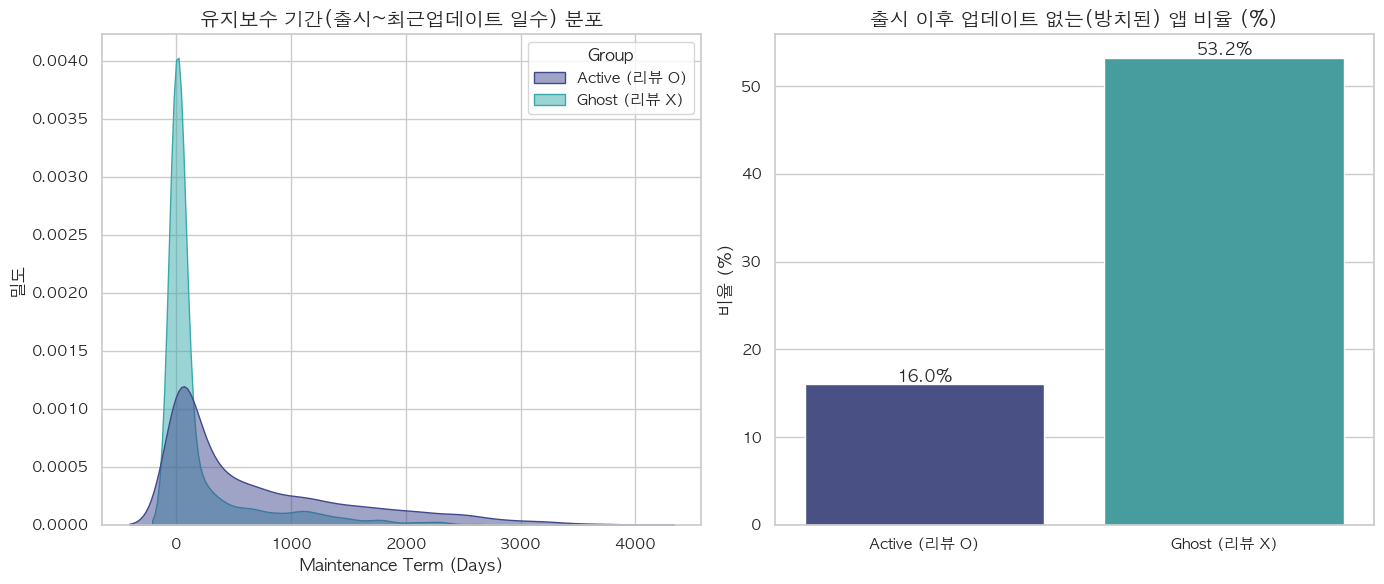

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 좌측: 유지보수 기간(일수) 분포 비교 (KDE plot)
sns.kdeplot(data=df_viz, x='Maintenance_Term', hue='Group', fill=True, common_norm=False, alpha=0.5, palette='mako', ax=axes[0])
axes[0].set_title('유지보수 기간(출시~최근업데이트 일수) 분포', fontsize=14, fontweight='bold')
axes[0].set_ylabel('밀도')
axes[0].set_xlabel('Maintenance Term (Days)')

# 우측: 유지보수 기간이 0인(출시 후 업데이트 없음) 앱의 비율 비교
# 0일인 경우 True, 아니면 False 인 임시 파생변수 생성
df_viz['Is_Abandoned'] = df_viz['Maintenance_Term'] == 0 
abandoned_ratio = df_viz.groupby('Group')['Is_Abandoned'].mean() * 100 # 비율(%) 계산

sns.barplot(x=abandoned_ratio.index, y=abandoned_ratio.values, palette='mako', ax=axes[1])
axes[1].set_title('출시 이후 업데이트 없는(방치된) 앱 비율 (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율 (%)')
axes[1].set_xlabel('')

# 막대 그래프 위에 퍼센트 수치 표시
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 출시연도별 트렌드

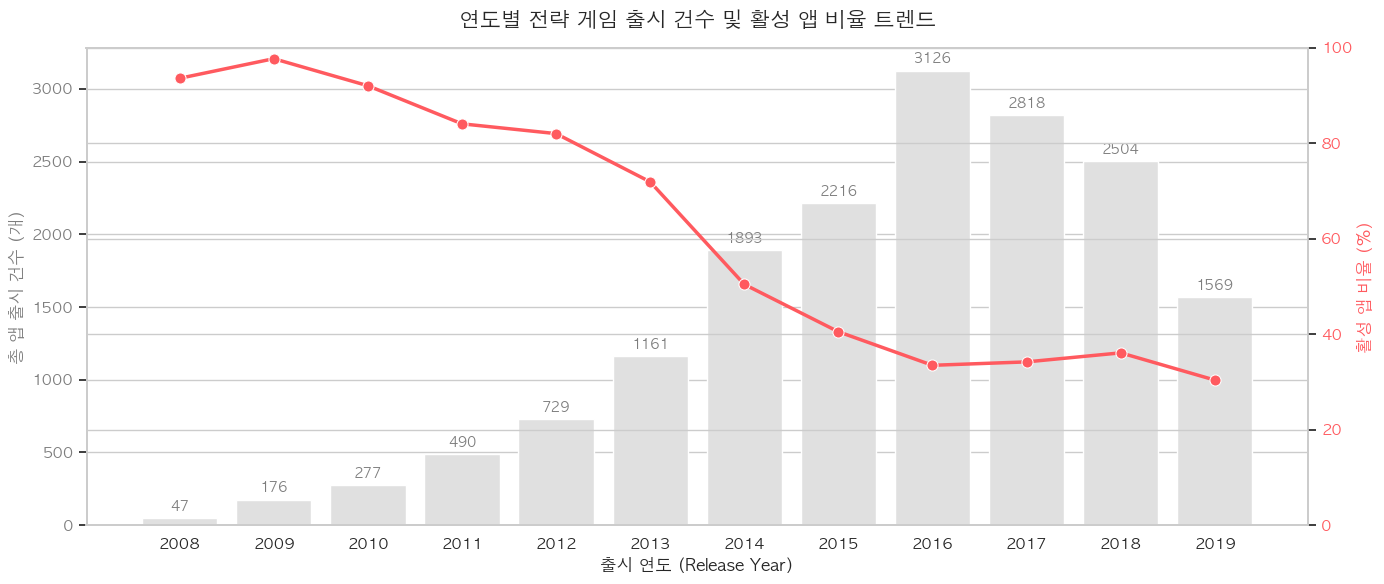

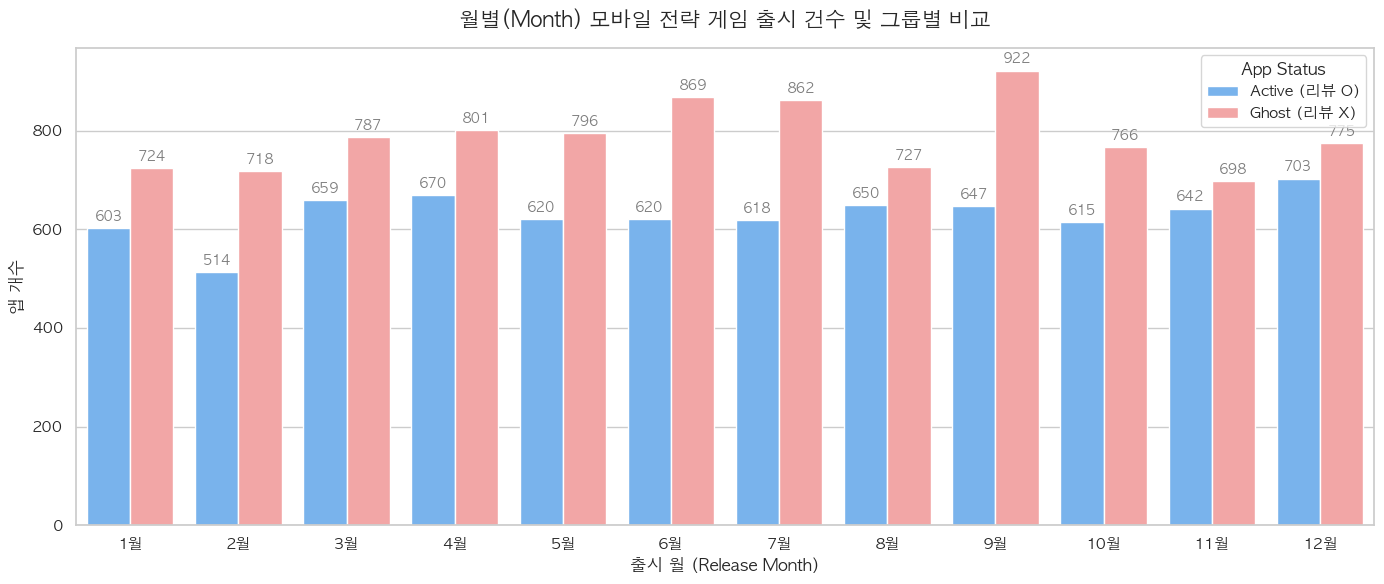

In [66]:
# ---------------------------------------------------
# [1] 연도별 시장 트렌드 및 활성도 변화 (이중 축 그래프)
# ---------------------------------------------------
# 연도별 총 앱 개수와 Active 앱 비율 계산
yearly_stats = df_viz.groupby('Release_Year').agg(
    Total_Apps=('ID', 'count'),
    Active_Count=('Group', lambda x: (x == 'Active (리뷰 O)').sum())
).reset_index()

yearly_stats['Active_Ratio (%)'] = (yearly_stats['Active_Count'] / yearly_stats['Total_Apps']) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# 왼쪽 Y축: 전체 앱 출시 건수 (막대그래프)
sns.barplot(data=yearly_stats, x='Release_Year', y='Total_Apps', color='#E0E0E0', ax=ax1)
ax1.set_title('연도별 전략 게임 출시 건수 및 활성 앱 비율 트렌드', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('출시 연도 (Release Year)')
ax1.set_ylabel('총 앱 출시 건수 (개)', color='#7D7D7D', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#7D7D7D')

# 막대 위에 출시 건수 텍스트 표시
for container in ax1.containers:
    ax1.bar_label(container, padding=3, fmt='%d', color='#7D7D7D', fontsize=10)

# 오른쪽 Y축: 활성 앱 비율 (꺾은선 그래프)
ax2 = ax1.twinx() # x축을 공유하는 새로운 y축 생성
sns.lineplot(data=yearly_stats, x=np.arange(len(yearly_stats)), y='Active_Ratio (%)', 
             marker='o', markersize=8, color='#FF5A5F', linewidth=2.5, ax=ax2)
ax2.set_ylabel('활성 앱 비율 (%)', color='#FF5A5F', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#FF5A5F')
ax2.set_ylim(0, 100) # 비율이므로 0~100%로 고정

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# [2] 월별 계절성 및 흥행 분석 (Countplot)
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))

sns.countplot(data=df_viz, x='Release_Month', hue='Group', palette=['#66B3FF', '#FF9999'], ax=ax)
ax.set_title('월별(Month) 모바일 전략 게임 출시 건수 및 그룹별 비교', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('출시 월 (Release Month)')
ax.set_ylabel('앱 개수')
ax.legend(title='App Status', loc='upper right')

# 막대 위에 출시 건수 텍스트 표시
for container in ax.containers:
    ax.bar_label(container, padding=3, fmt='%d', color='#7D7D7D', fontsize=10)

# X축 눈금을 1월~12월 형태로 변경
ax.set_xticks(range(12))
ax.set_xticklabels([f'{i}월' for i in range(1, 13)])

plt.tight_layout()
plt.show()

### 리뷰(User Rating) : Active 그룹 대상

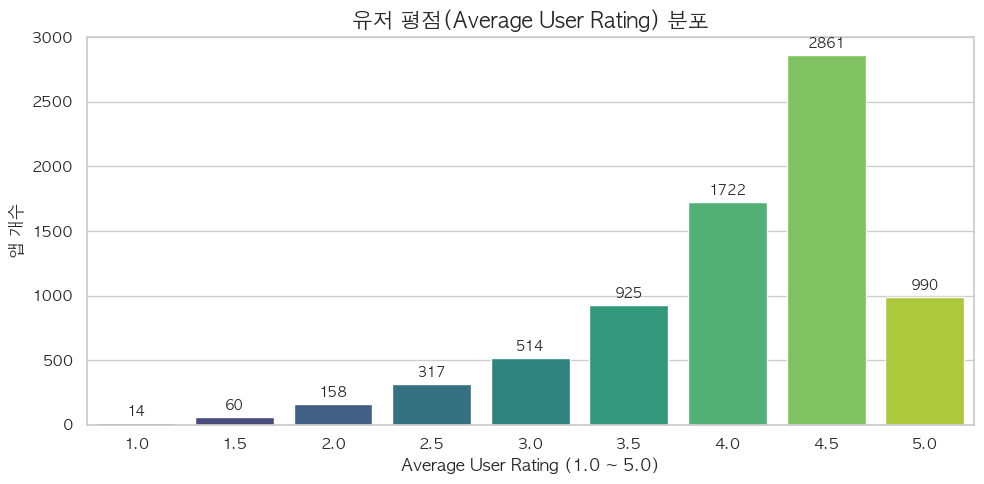

In [43]:
# 1. 타겟 변수(평점) 분포 시각화 (1x1)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_with_ratings, x='Average User Rating', palette='viridis')
plt.title('유저 평점(Average User Rating) 분포', fontsize=15, fontweight='bold')
plt.xlabel('Average User Rating (1.0 ~ 5.0)')
plt.ylabel('앱 개수')

# 막대 위에 개수 텍스트 표시
for container in plt.gca().containers:
    plt.gca().bar_label(container, padding=3, fmt='%d', fontsize=10)

plt.tight_layout()
plt.show()

#### 리뷰 심화

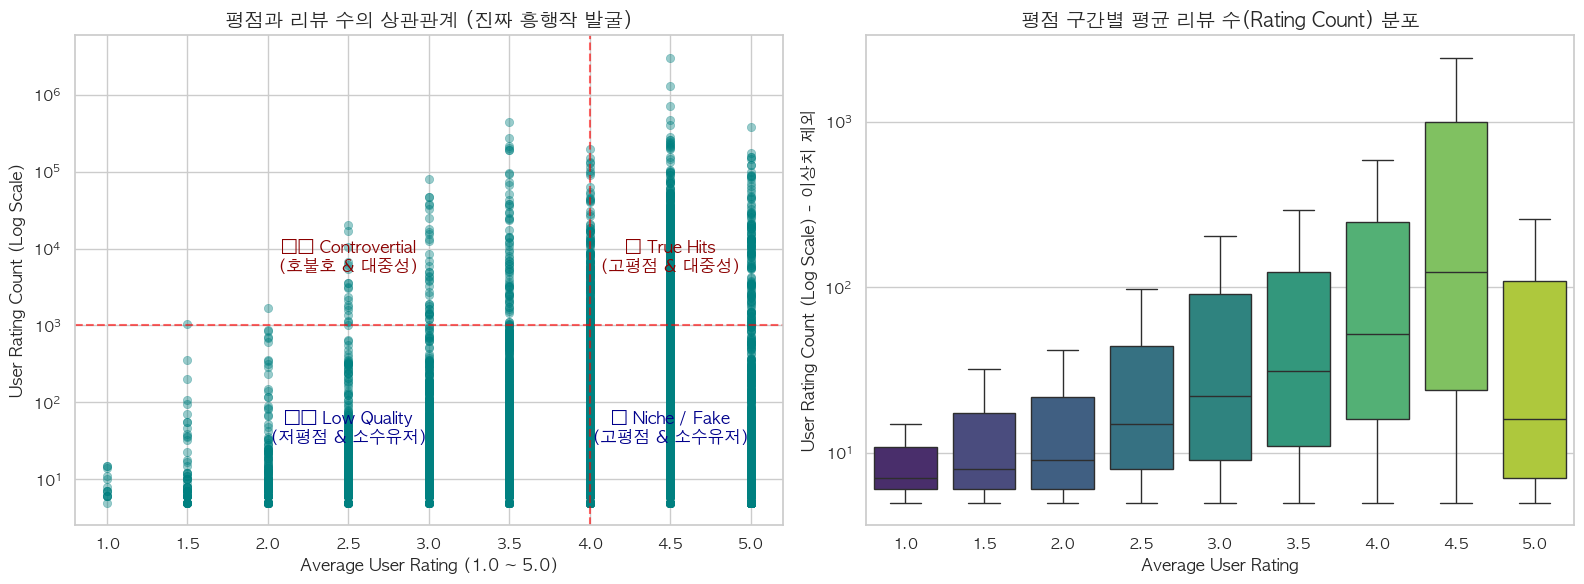

In [ ]:
# 심화 EDA : Rating 과 Review Count 교차분석

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 좌측: 평점과 리뷰 수의 산점도 (4사분면 매트릭스) ---
sns.scatterplot(data=df_with_ratings, x='Average User Rating', y='User Rating Count', 
                alpha=0.4, color='teal', edgecolor=None, ax=axes[0])
axes[0].set_yscale('log') # 리뷰 수 편차가 크므로 Y축 로그 스케일 적용

# 의미 있는 비즈니스 기준선(Threshold) 긋기
# (예: 평점 4.0 이상 & 리뷰 수 1,000개 이상을 '진짜 흥행작'으로 정의)
axes[0].axvline(4.0, color='red', linestyle='--', alpha=0.6)
axes[0].axhline(1000, color='red', linestyle='--', alpha=0.6)

# 각 사분면에 텍스트 라벨 추가 (포트폴리오 가독성 극대화)
axes[0].text(4.5, 5000, '👑 True Hits\n(고평점 & 대중성)', color='darkred', fontweight='bold', ha='center')
axes[0].text(2.5, 5000, '⚠️ Controvertial\n(호불호 & 대중성)', color='darkred', fontweight='bold', ha='center')
axes[0].text(4.5, 30, '👻 Niche / Fake\n(고평점 & 소수유저)', color='darkblue', fontweight='bold', ha='center')
axes[0].text(2.5, 30, '🗑️ Low Quality\n(저평점 & 소수유저)', color='darkblue', fontweight='bold', ha='center')

axes[0].set_title('평점과 리뷰 수의 상관관계', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average User Rating (1.0 ~ 5.0)')
axes[0].set_ylabel('User Rating Count (Log Scale)')


# --- 우측: 평점 구간별 리뷰 수의 분포 (Boxplot) ---
sns.boxplot(data=df_with_ratings, x='Average User Rating', y='User Rating Count', 
            palette='viridis', ax=axes[1], showfliers=False)
axes[1].set_yscale('log') # Y축 로그 스케일

axes[1].set_title('평점 구간별 평균 리뷰 수(Rating Count) 분포', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average User Rating')
axes[1].set_ylabel('User Rating Count (Log Scale) - 이상치 제외')

plt.tight_layout()
plt.show()

💡 [분석 기준] 상위 20% 평점 커트라인: 4.5점
💡 [분석 기준] 상위 20% 리뷰 수 커트라인: 557개


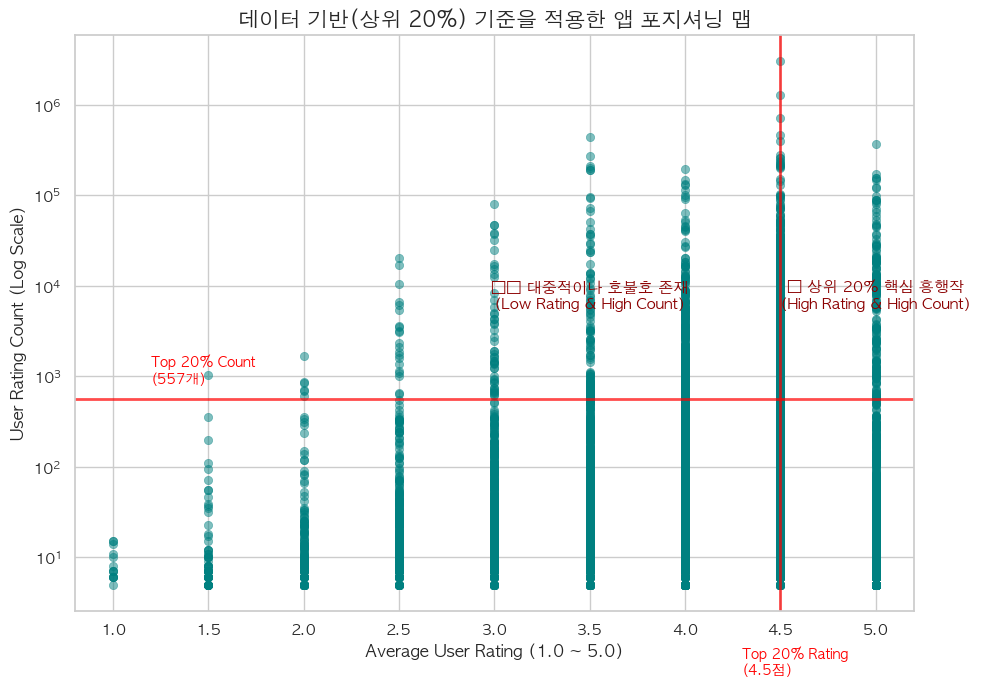

In [60]:
# 1. 동적 기준선 계산 (상위 20% - 파레토 법칙 적용)
# quantile(0.8)은 하위 80% 위치의 값을 의미하므로, 상위 20%의 커트라인이 됩니다.
top_20_rating = df_with_ratings['Average User Rating'].quantile(0.8)
top_20_count = df_with_ratings['User Rating Count'].quantile(0.8)

# 포트폴리오(또는 출력창)에 계산된 기준을 명시적으로 보여주기 위한 프린트문
print(f"💡 [분석 기준] 상위 20% 평점 커트라인: {top_20_rating}점")
print(f"💡 [분석 기준] 상위 20% 리뷰 수 커트라인: {top_20_count:,.0f}개")

# 2. 시각화 (산점도)
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(data=df_with_ratings, x='Average User Rating', y='User Rating Count', 
                alpha=0.5, color='teal', edgecolor=None, ax=ax)
ax.set_yscale('log')

# 3. 계산된 동적 기준선(Threshold) 그리기
ax.axvline(top_20_rating, color='red', linestyle='-', alpha=0.7, linewidth=2)
ax.axhline(top_20_count, color='red', linestyle='-', alpha=0.7, linewidth=2)

# 기준선에 대한 텍스트 라벨 추가
ax.text(top_20_rating - 0.2, 0.5, f'Top 20% Rating\n({top_20_rating}점)', color='red', fontsize=10)
ax.text(1.2, top_20_count * 1.5, f'Top 20% Count\n({top_20_count:,.0f}개)', color='red', fontsize=10)

# 각 사분면에 텍스트 라벨 추가 (위치값도 동적 기준에 맞춰 대략적으로 자동화)
ax.text(top_20_rating + 0.5, top_20_count * 10, '👑 상위 20% 핵심 흥행작\n(High Rating & High Count)', 
        color='darkred', fontweight='bold', ha='center', fontsize=11)
ax.text(top_20_rating - 1, top_20_count * 10, '⚠️ 대중적이나 호불호 존재\n(Low Rating & High Count)', 
        color='darkred', fontweight='bold', ha='center', fontsize=11)

ax.set_title('데이터 기반(상위 20%) 기준을 적용한 앱 포지셔닝 맵', fontsize=15, fontweight='bold')
ax.set_xlabel('Average User Rating (1.0 ~ 5.0)')
ax.set_ylabel('User Rating Count (Log Scale)')

plt.tight_layout()
plt.show()

In [ ]:
# Price 및 IAP_Mean vs 평점 시각화 (1x2 서브플롯 2세트)
# --- [1] Price (앱 가격) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 좌측: Price 분포도 (유료 앱만 필터링하여 로그 스케일 적용)
paid_apps = df_with_ratings[df_with_ratings['Price'] > 0]
sns.histplot(data=paid_apps, x='Price', bins=30, kde=True, ax=axes[0], color='coral')
axes[0].set_yscale('log') # 가격 분포의 꼬리가 매우 길기 때문에 Y축 로그 스케일
axes[0].set_title('유료 앱 가격(Price) 분포 (Y Log Scale)', fontsize=13, fontweight='bold')

# 우측: 평점별 Price 박스플롯 (이상치 제외)
sns.boxplot(data=df_with_ratings, x='Average User Rating', y='Price', palette='viridis', ax=axes[1], showfliers=False)
axes[1].set_title('평점별 Price 분포 비교 (이상치 제외)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


# --- [2] IAP_Mean (인앱 결제 평균) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 인앱 결제가 있는 데이터만 필터링
df_iap_active = df_with_ratings[df_with_ratings['IAP_Mean'] > 0]

# 좌측: IAP_Mean 분포도
sns.histplot(data=df_iap_active, x='IAP_Mean', bins=30, kde=True, ax=axes[0], color='mediumseagreen')
axes[0].set_title('인앱 결제 평균액(IAP_Mean) 분포', fontsize=13, fontweight='bold')

# 우측: 평점별 IAP_Mean 박스플롯 (이상치 제외)
sns.boxplot(data=df_iap_active, x='Average User Rating', y='IAP_Mean', palette='viridis', ax=axes[1], showfliers=False)
axes[1].set_title('평점별 IAP_Mean 분포 비교 (이상치 제외)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

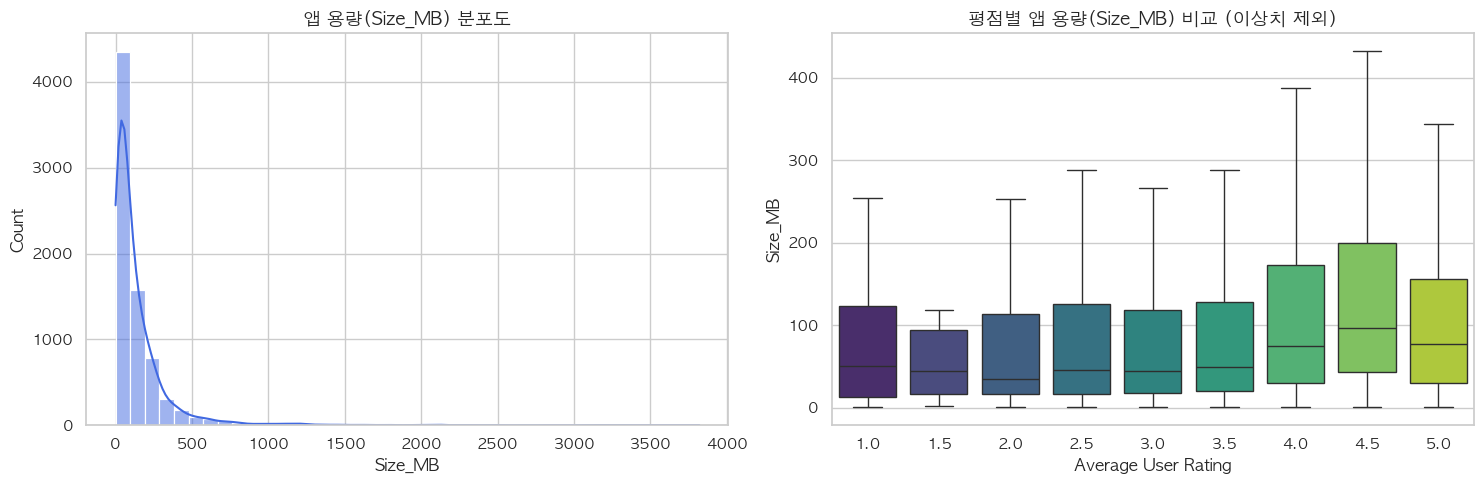

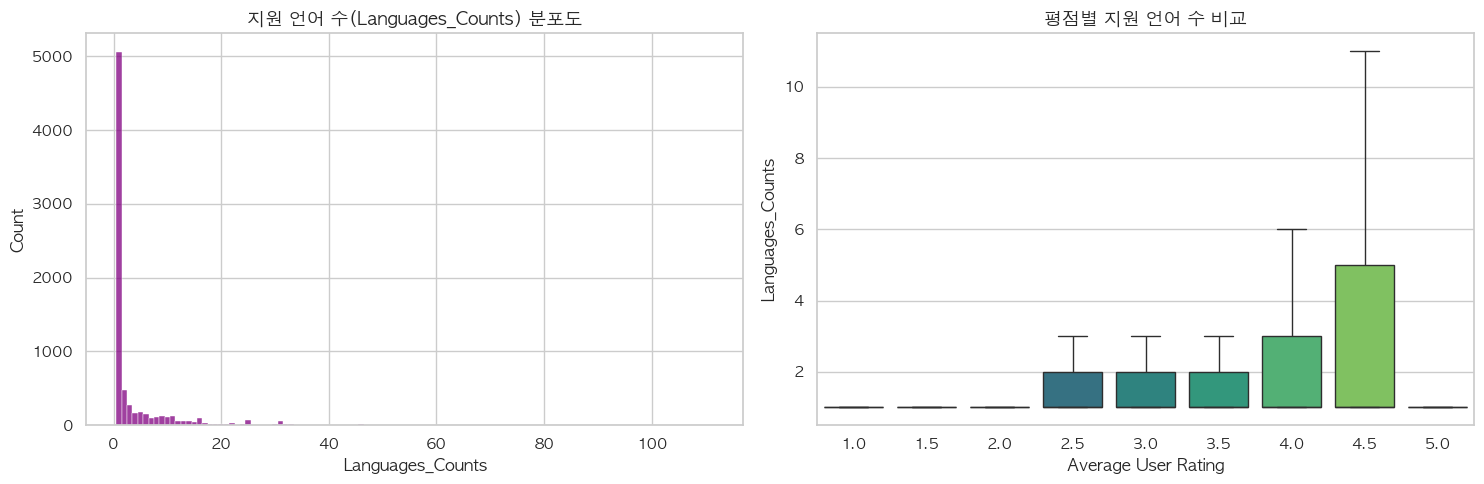

In [45]:
# 3. Size_MB 및 Languages_Counts vs 평점 시각화

# --- [1] Size_MB (앱 용량) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df_with_ratings, x='Size_MB', bins=40, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('앱 용량(Size_MB) 분포도', fontsize=13, fontweight='bold')

sns.boxplot(data=df_with_ratings, x='Average User Rating', y='Size_MB', palette='viridis', ax=axes[1], showfliers=False)
axes[1].set_title('평점별 앱 용량(Size_MB) 비교 (이상치 제외)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


# --- [2] Languages_Counts (지원 언어 수) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df_with_ratings, x='Languages_Counts', discrete=True, ax=axes[0], color='purple')
axes[0].set_title('지원 언어 수(Languages_Counts) 분포도', fontsize=13, fontweight='bold')

sns.boxplot(data=df_with_ratings, x='Average User Rating', y='Languages_Counts', palette='viridis', ax=axes[1], showfliers=False)
axes[1].set_title('평점별 지원 언어 수 비교', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Active 그룹 종합 시각화

#### 상관관계

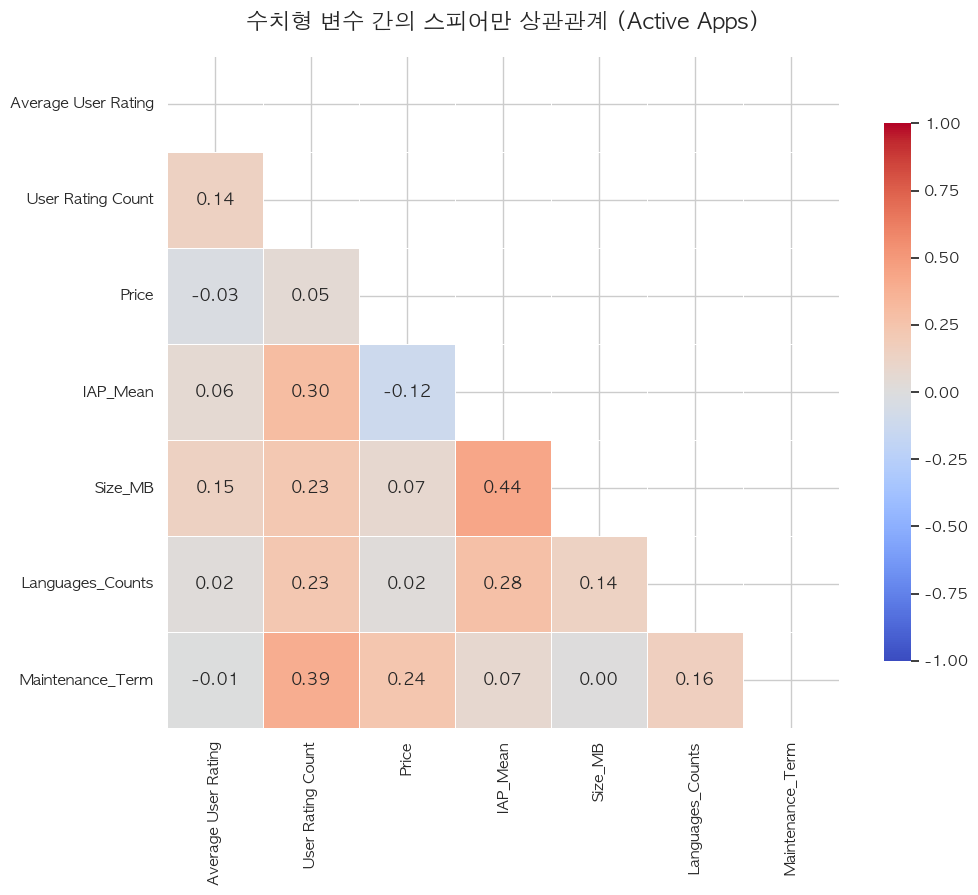

In [62]:
# 1. 분석 대상 수치형 변수 리스트 설정
target_cols = [
    'Average User Rating', 'User Rating Count', 'Price', 
    'IAP_Mean', 'Size_MB', 'Languages_Counts', 'Maintenance_Term'
]

# 2. 지정된 변수들로 스피어만(Spearman) 상관계수 행렬 계산
corr_matrix = df_with_ratings[target_cols].corr(method='spearman')

# 3. 가독성을 위한 마스크 생성 (대각선 위쪽을 True로 만들어서 가림)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. 시각화 세팅 및 히트맵 그리기
fig, ax = plt.subplots(figsize=(11, 9))

# coolwarm 컬러맵 사용, vmin과 vmax를 -1과 1로 고정하여 색상 대비를 명확히 함
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, 
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .8}, 
            ax=ax)

ax.set_title('수치형 변수 간의 스피어만 상관관계 (Active Apps)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

#### 구간화 및 구간별 중앙값 비교

💡 [그룹별 핵심 지표 중앙값 요약]


,Rating_Group,Size_MB,Maintenance_Term,IAP_Mean,Languages_Counts
0,High_Rated (4.5 이상),89.37,345.0,4.99,1.0
1,Low_Rated (4.5 미만),57.34,338.5,3.69,1.0


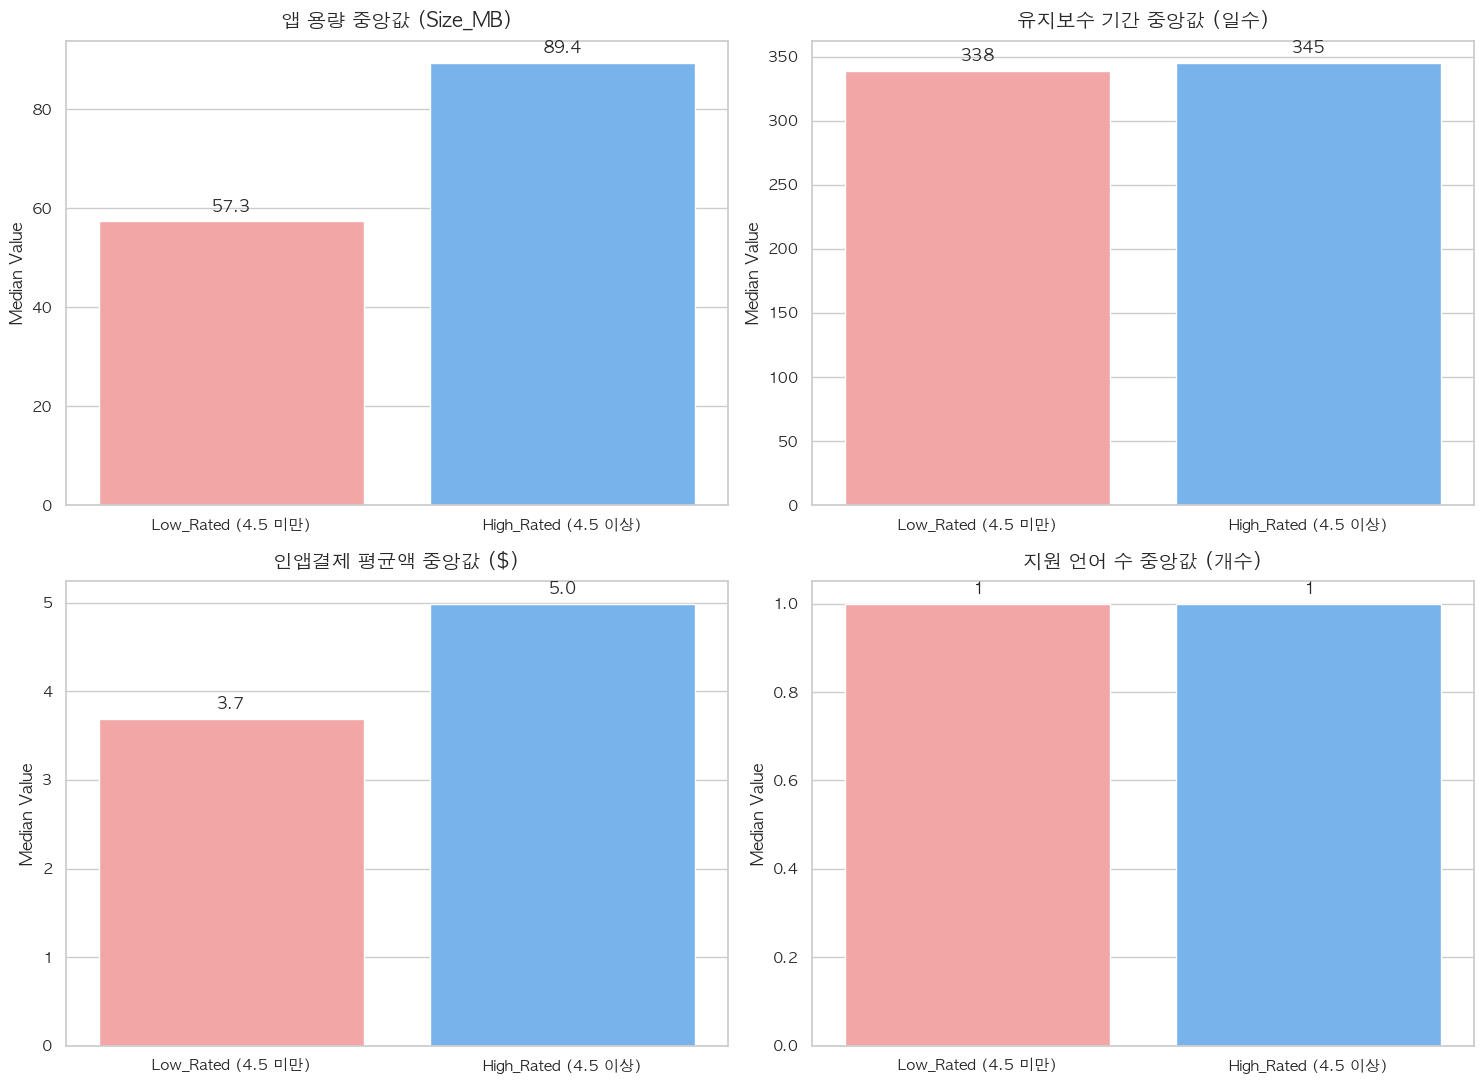

In [63]:
# 1. 파생 변수(구간화) 생성: 평점 4.5 기준으로 High_Rated와 Low_Rated 구분
df_with_ratings['Rating_Group'] = np.where(
    df_with_ratings['Average User Rating'] >= 4.5, 
    'High_Rated (4.5 이상)', 
    'Low_Rated (4.5 미만)'
)

# 2. 그룹별 핵심 지표 중앙값(Median) 계산
target_cols = ['Size_MB', 'Maintenance_Term', 'IAP_Mean', 'Languages_Counts']
median_summary = df_with_ratings.groupby('Rating_Group')[target_cols].median().reset_index()

# 포트폴리오 첨부용 중앙값 테이블 출력
print("💡 [그룹별 핵심 지표 중앙값 요약]")
display(median_summary)

# 3. 2x2 서브플롯 형태의 막대그래프 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten() # 2D 배열을 1D로 펴서 반복문 적용을 쉽게 함

# 시각화용 타이틀 및 포맷 세팅
titles = ['앱 용량 중앙값 (Size_MB)', '유지보수 기간 중앙값 (일수)', 
          '인앱결제 평균액 중앙값 ($)', '지원 언어 수 중앙값 (개수)']
colors = ['#FF9999', '#66B3FF'] # Low(Red 계열) vs High(Blue 계열) 대비

for i, col in enumerate(target_cols):
    sns.barplot(
        data=median_summary, 
        x='Rating_Group', 
        y=col, 
        palette=colors, 
        ax=axes[i], 
        order=['Low_Rated (4.5 미만)', 'High_Rated (4.5 이상)'] # 비교를 위해 순서 고정
    )
    axes[i].set_title(titles[i], fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Median Value')
    
    # 막대 위에 중앙값 숫자 표시
    for container in axes[i].containers:
        # Maintenance_Term과 Languages_Counts는 정수로, 나머지는 소수점 1자리로 표기
        fmt_str = '%d' if col in ['Maintenance_Term', 'Languages_Counts'] else '%.1f'
        axes[i].bar_label(container, padding=5, fmt=fmt_str, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Active vs Ghost 종합 시각화

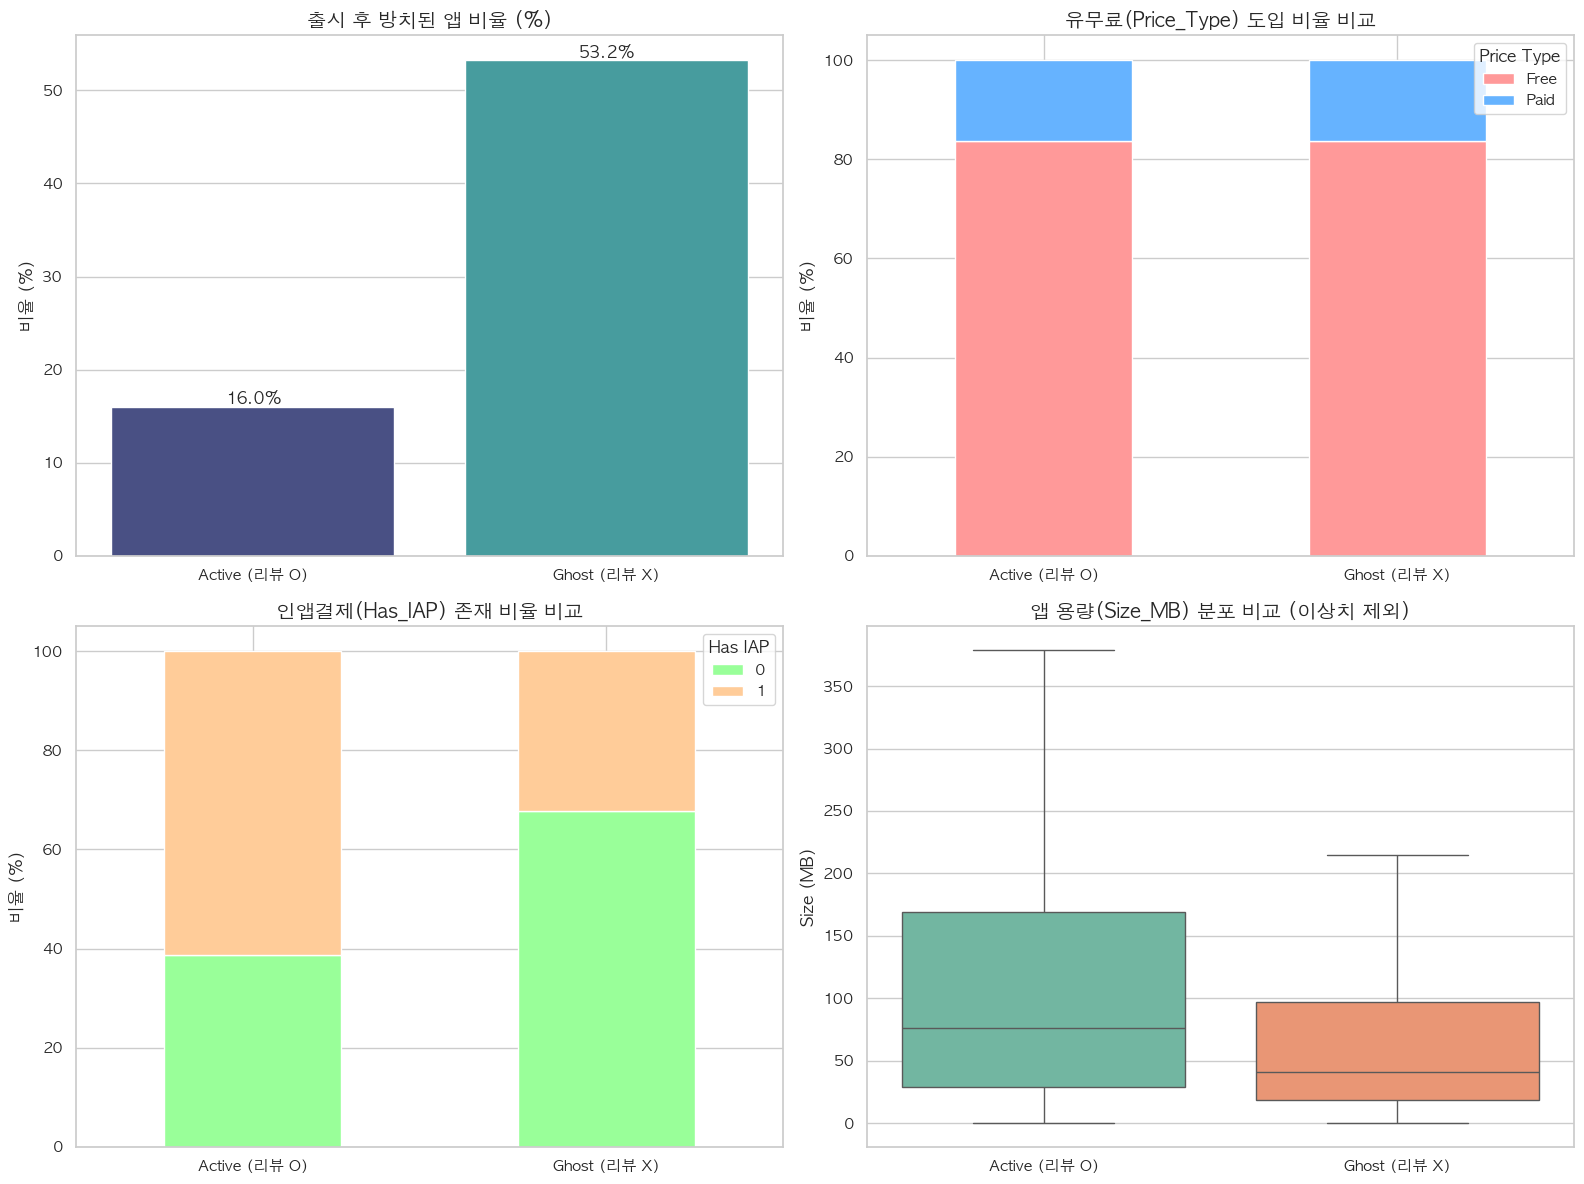

In [64]:
# 서브플롯 세팅
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------------------
# [1] 방치된 앱 비율 비교 (Maintenance_Term == 0)
# ---------------------------------------------------
# 유지보수 기간이 0인(업데이트 없는) 앱 여부 파생변수 생성
df_viz['Is_Abandoned'] = (df_viz['Maintenance_Term'] == 0)
abandoned_rates = df_viz.groupby('Group')['Is_Abandoned'].mean() * 100

sns.barplot(x=abandoned_rates.index, y=abandoned_rates.values, palette='mako', ax=axes[0, 0])
axes[0, 0].set_title('출시 후 방치된 앱 비율 (%)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('비율 (%)')
axes[0, 0].set_xlabel('')

# 막대 위에 퍼센트 수치 표시
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{p.get_height():.1f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=12, fontweight='bold')

# ---------------------------------------------------
# [2] 수익화 모델: 유무료(Price_Type) 비율 100% 누적 막대그래프
# ---------------------------------------------------
price_crosstab = pd.crosstab(df_viz['Group'], df_viz['Price_Type'], normalize='index') * 100
price_crosstab.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['#FF9999', '#66B3FF'])

axes[0, 1].set_title('유무료(Price_Type) 도입 비율 비교', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('비율 (%)')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=0) # X축 글자 수평 정렬
axes[0, 1].legend(title='Price Type', loc='upper right')

# ---------------------------------------------------
# [3] 수익화 모델: 인앱결제(Has_IAP) 비율 100% 누적 막대그래프
# ---------------------------------------------------
iap_crosstab = pd.crosstab(df_viz['Group'], df_viz['Has_IAP'], normalize='index') * 100
iap_crosstab.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#99FF99', '#FFCC99'])

axes[1, 0].set_title('인앱결제(Has_IAP) 존재 비율 비교', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('비율 (%)')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(title='Has IAP', loc='upper right')

# ---------------------------------------------------
# [4] 앱 스펙(용량) 비교 (Size_MB) - 이상치 제외 박스플롯
# ---------------------------------------------------
sns.boxplot(data=df_viz, x='Group', y='Size_MB', palette='Set2', showfliers=False, ax=axes[1, 1])
axes[1, 1].set_title('앱 용량(Size_MB) 분포 비교 (이상치 제외)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Size (MB)')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()